# Assignment 05: Exploratory Data Analysis & Data Cleaning

Complete EDA and data cleaning for three datasets:
1. **Loan Eligibility Dataset**
2. **Adult Census Income Dataset**
3. **Hotel Booking Dataset**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


---
# Dataset 1: Loan Eligibility

Loading the loan dataset and performing complete EDA and data cleaning.


In [2]:
loan_df = pd.read_csv('loan-train.csv')
loan_original = loan_df.copy()
print('Shape:', loan_df.shape)
loan_df.head()


Shape: (1614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
loan_df.info()
print('\n--- Data Types ---')
print(loan_df.dtypes)
print('\n--- Statistical Summary (Numerical) ---')
loan_df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1601 non-null   str    
 2   Married            1611 non-null   str    
 3   Dependents         1599 non-null   str    
 4   Education          1614 non-null   str    
 5   Self_Employed      1582 non-null   str    
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 164.1 KB

--- Data Types ---
Loan_ID                  str
Gender                   str
Married                  str
Dependents       

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1614.000000,1614.000000,1592.000000,1600.000000,1564.00000
mean,8746.304833,3658.722999,218.846734,290.475000,0.63555
std,6249.885122,3291.745935,133.623293,81.899735,0.48143
min,150.000000,0.000000,9.000000,12.000000,0.00000
25%,3675.250000,986.250000,112.000000,240.000000,0.00000
50%,7045.000000,2941.500000,180.000000,360.000000,1.00000
75%,13251.000000,5893.000000,324.000000,360.000000,1.00000
max,81000.000000,41667.000000,700.000000,480.000000,1.00000


In [4]:
print('--- Statistical Summary (Categorical) ---')
loan_df.describe(include='object')


--- Statistical Summary (Categorical) ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,1614,1601,1611,1599,1614,1582,1614,1614
unique,1538,2,2,4,2,2,3,2
top,LP006706,Male,Yes,0,Graduate,No,Urban,Y
freq,3,980,925,619,952,999,549,915


## Missing Values Analysis


In [5]:
missing_loan = loan_df.isnull().sum()
missing_pct_loan = (missing_loan / len(loan_df) * 100).round(2)
missing_df_loan = pd.DataFrame({'Missing Count': missing_loan, 'Missing %': missing_pct_loan})
missing_df_loan[missing_df_loan['Missing Count'] > 0]


,Missing Count,Missing %
Gender,13,0.81
Married,3,0.19
Dependents,15,0.93
Self_Employed,32,1.98
LoanAmount,22,1.36
Loan_Amount_Term,14,0.87
Credit_History,50,3.10


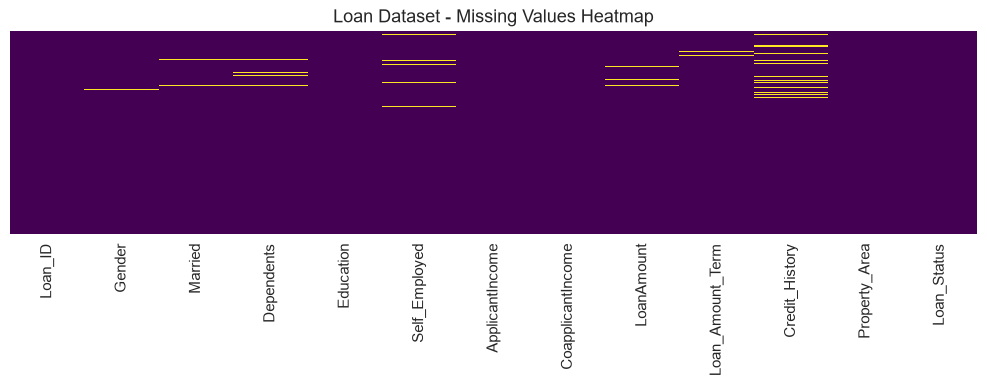

In [6]:
plt.figure(figsize=(10, 4))
sns.heatmap(loan_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Loan Dataset - Missing Values Heatmap')
plt.tight_layout()
plt.show()


## Duplicate Records


In [7]:
print('Duplicate rows:', loan_df.duplicated().sum())
print('Duplicate Loan_IDs:', loan_df['Loan_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Loan_IDs: 76


## Column-wise Analysis

Analyzing every column individually.


### `Loan_ID`

Unique identifier for each loan application.


--- Loan_ID ---
Unique values: 1538
Missing: 0
Loan_ID
LP006706    3
LP003002    2
LP003029    2
LP003103    2
LP003139    2
           ..
LP009965    1
LP009966    1
LP009970    1
LP009977    1
LP009996    1
Name: count, Length: 1538, dtype: int64


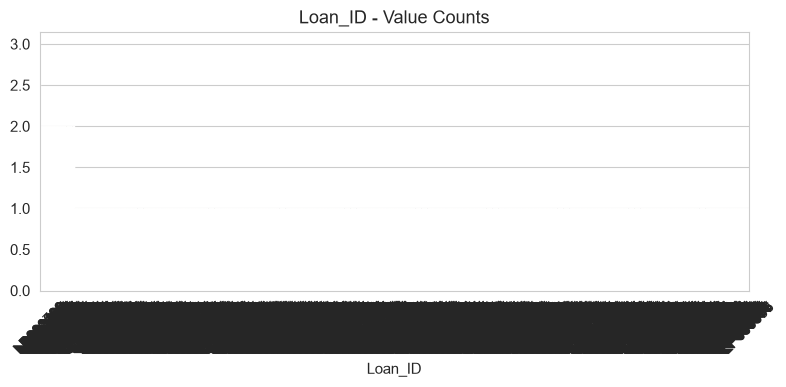

In [8]:
print('--- Loan_ID ---')
print(f"Unique values: {loan_df['Loan_ID'].nunique()}")
print(f"Missing: {loan_df['Loan_ID'].isnull().sum()}")
print(loan_df['Loan_ID'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Loan_ID'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Loan_ID - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Gender`

Gender of the applicant.


--- Gender ---
Unique values: 2
Missing: 13
Gender
Male      980
Female    621
NaN        13
Name: count, dtype: int64


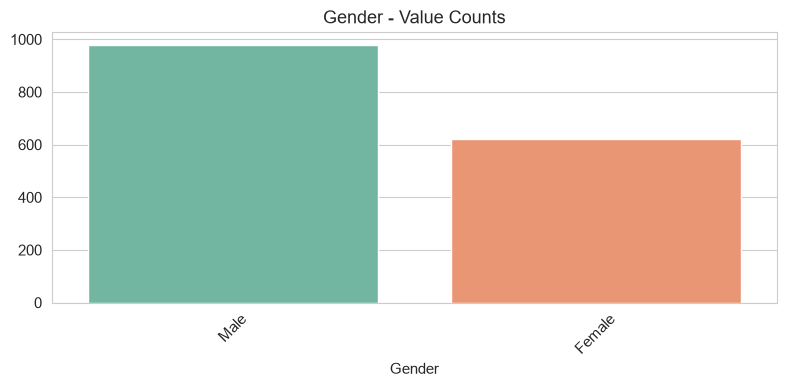

In [9]:
print('--- Gender ---')
print(f"Unique values: {loan_df['Gender'].nunique()}")
print(f"Missing: {loan_df['Gender'].isnull().sum()}")
print(loan_df['Gender'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Gender'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Gender - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Married`

Marital status of the applicant.


--- Married ---
Unique values: 2
Missing: 3
Married
Yes    925
No     686
NaN      3
Name: count, dtype: int64


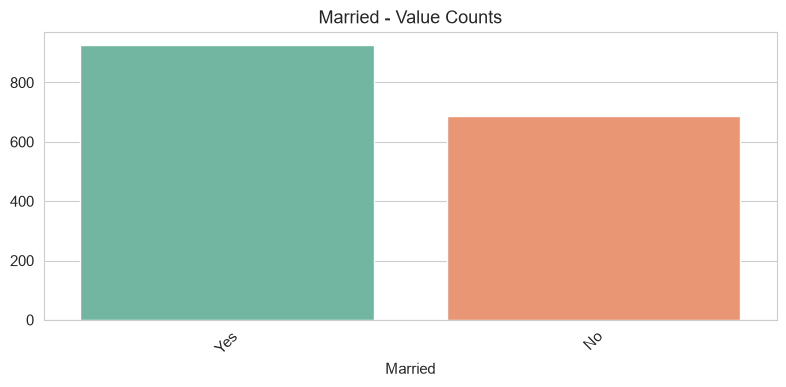

In [10]:
print('--- Married ---')
print(f"Unique values: {loan_df['Married'].nunique()}")
print(f"Missing: {loan_df['Married'].isnull().sum()}")
print(loan_df['Married'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Married'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Married - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Dependents`

Number of dependents.


--- Dependents ---
Unique values: 4
Missing: 15
Dependents
0      619
1      341
2      336
3+     303
NaN     15
Name: count, dtype: int64


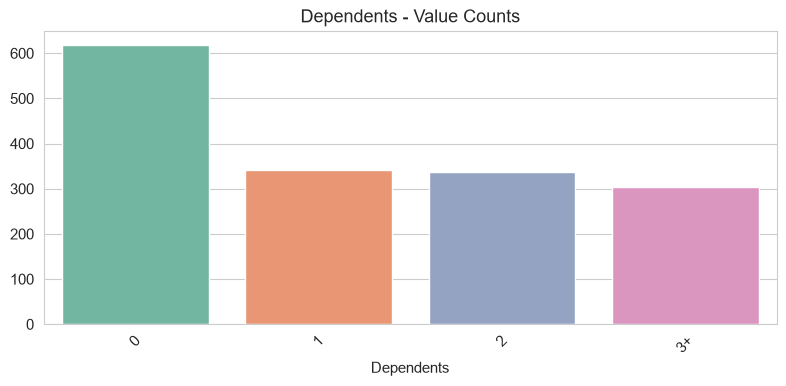

In [11]:
print('--- Dependents ---')
print(f"Unique values: {loan_df['Dependents'].nunique()}")
print(f"Missing: {loan_df['Dependents'].isnull().sum()}")
print(loan_df['Dependents'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Dependents'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Dependents - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Education`

Education level of the applicant.


--- Education ---
Unique values: 2
Missing: 0
Education
Graduate        952
Not Graduate    662
Name: count, dtype: int64


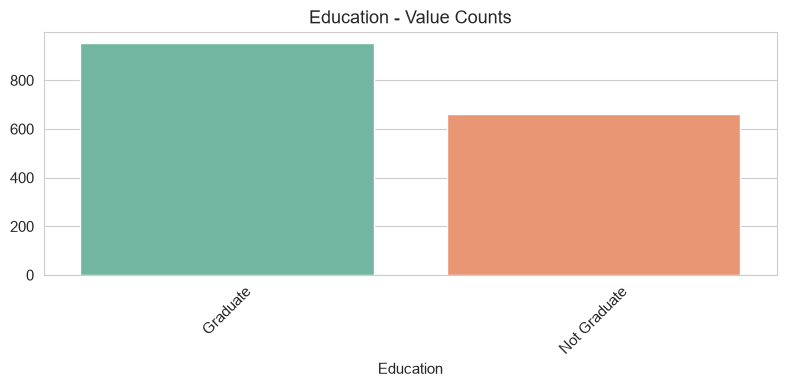

In [12]:
print('--- Education ---')
print(f"Unique values: {loan_df['Education'].nunique()}")
print(f"Missing: {loan_df['Education'].isnull().sum()}")
print(loan_df['Education'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Education'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Education - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Self_Employed`

Whether the applicant is self-employed.


--- Self_Employed ---
Unique values: 2
Missing: 32
Self_Employed
No     999
Yes    583
NaN     32
Name: count, dtype: int64


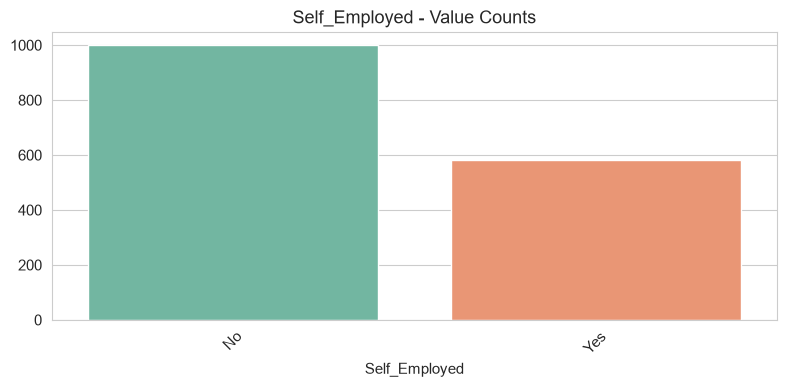

In [13]:
print('--- Self_Employed ---')
print(f"Unique values: {loan_df['Self_Employed'].nunique()}")
print(f"Missing: {loan_df['Self_Employed'].isnull().sum()}")
print(loan_df['Self_Employed'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Self_Employed'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Self_Employed - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `ApplicantIncome`

Income of the applicant.


--- ApplicantIncome ---
count     1614.000000
mean      8746.304833
std       6249.885122
min        150.000000
25%       3675.250000
50%       7045.000000
75%      13251.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64
Skewness: 2.16
Missing: 0


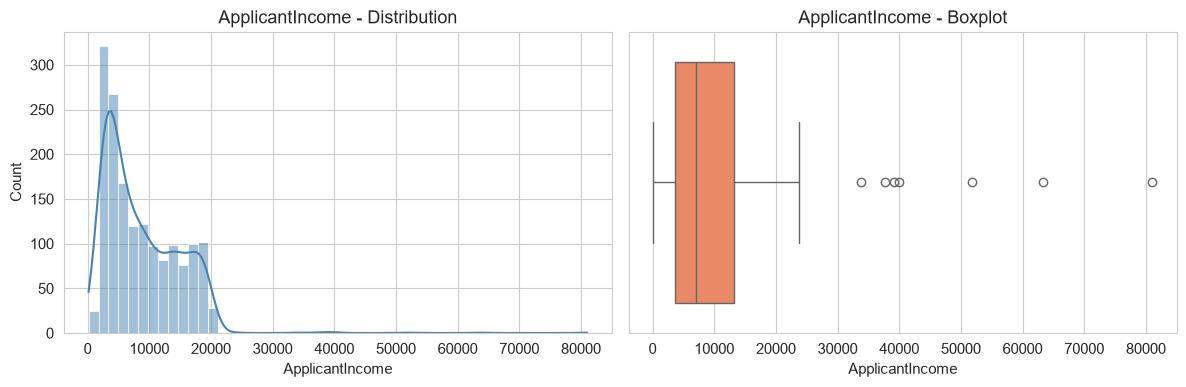

In [14]:
print('--- ApplicantIncome ---')
print(loan_df['ApplicantIncome'].describe())
print(f"Skewness: {loan_df['ApplicantIncome'].skew():.2f}")
print(f"Missing: {loan_df['ApplicantIncome'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['ApplicantIncome'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('ApplicantIncome - Distribution')
sns.boxplot(x=loan_df['ApplicantIncome'], ax=axes[1], color='coral')
axes[1].set_title('ApplicantIncome - Boxplot')
plt.tight_layout()
plt.show()


### `CoapplicantIncome`

Income of the co-applicant.


--- CoapplicantIncome ---
count     1614.000000
mean      3658.722999
std       3291.745935
min          0.000000
25%        986.250000
50%       2941.500000
75%       5893.000000
max      41667.000000
Name: CoapplicantIncome, dtype: float64
Skewness: 1.91
Missing: 0


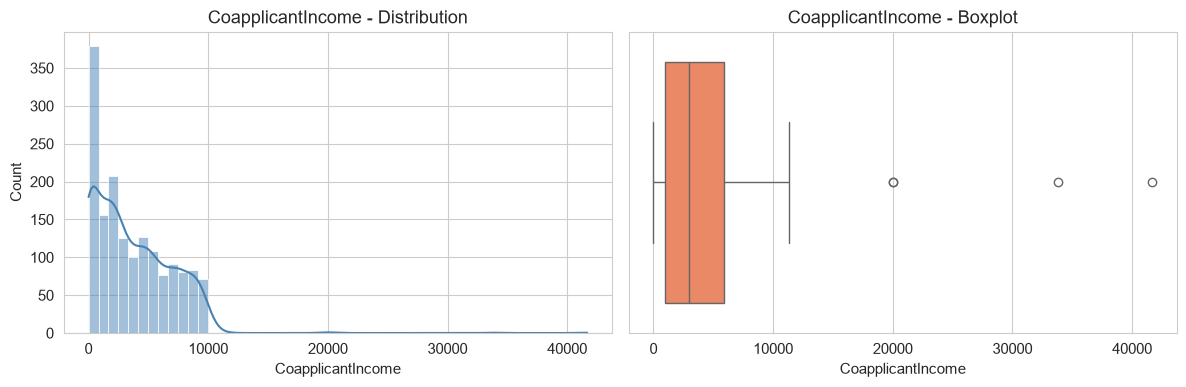

In [15]:
print('--- CoapplicantIncome ---')
print(loan_df['CoapplicantIncome'].describe())
print(f"Skewness: {loan_df['CoapplicantIncome'].skew():.2f}")
print(f"Missing: {loan_df['CoapplicantIncome'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['CoapplicantIncome'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('CoapplicantIncome - Distribution')
sns.boxplot(x=loan_df['CoapplicantIncome'], ax=axes[1], color='coral')
axes[1].set_title('CoapplicantIncome - Boxplot')
plt.tight_layout()
plt.show()


### `LoanAmount`

Loan amount requested (in thousands).


--- LoanAmount ---
count    1592.000000
mean      218.846734
std       133.623293
min         9.000000
25%       112.000000
50%       180.000000
75%       324.000000
max       700.000000
Name: LoanAmount, dtype: float64
Skewness: 0.60
Missing: 22


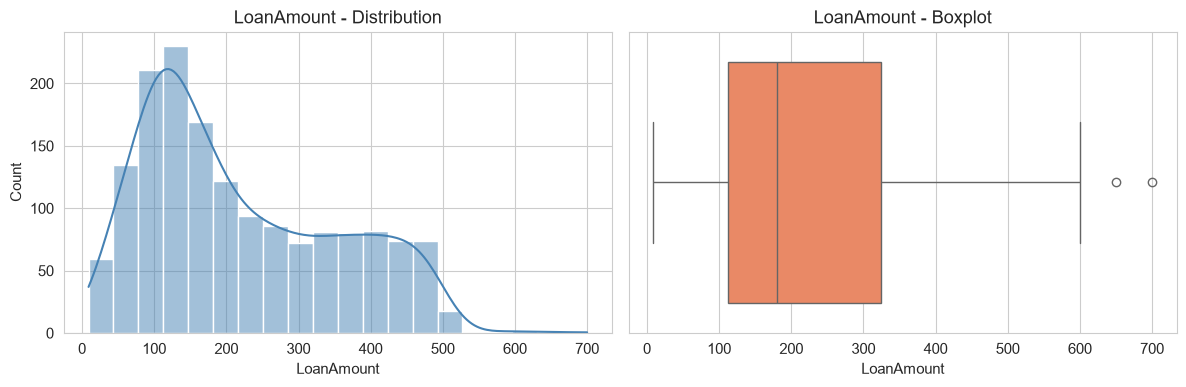

In [16]:
print('--- LoanAmount ---')
print(loan_df['LoanAmount'].describe())
print(f"Skewness: {loan_df['LoanAmount'].skew():.2f}")
print(f"Missing: {loan_df['LoanAmount'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['LoanAmount'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('LoanAmount - Distribution')
sns.boxplot(x=loan_df['LoanAmount'], ax=axes[1], color='coral')
axes[1].set_title('LoanAmount - Boxplot')
plt.tight_layout()
plt.show()


### `Loan_Amount_Term`

Term of the loan in days.


--- Loan_Amount_Term ---
count    1600.000000
mean      290.475000
std        81.899735
min        12.000000
25%       240.000000
50%       360.000000
75%       360.000000
max       480.000000
Name: Loan_Amount_Term, dtype: float64
Skewness: -0.35
Missing: 14


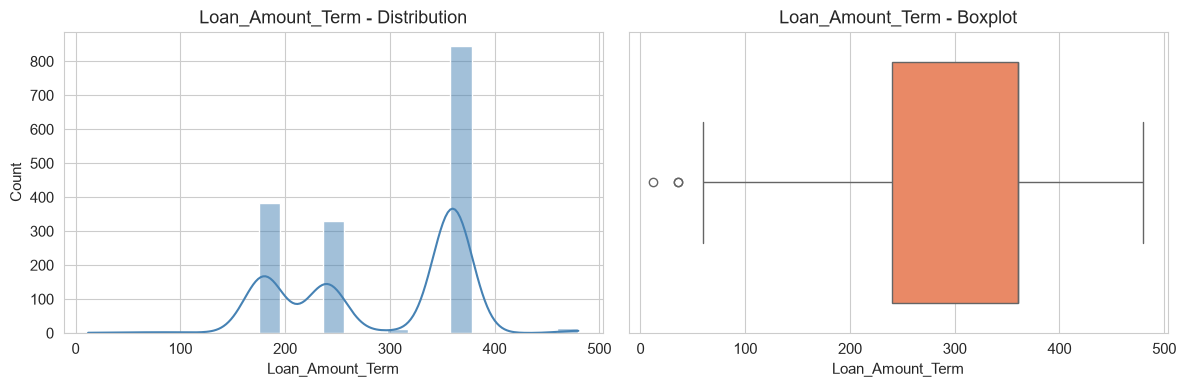

In [17]:
print('--- Loan_Amount_Term ---')
print(loan_df['Loan_Amount_Term'].describe())
print(f"Skewness: {loan_df['Loan_Amount_Term'].skew():.2f}")
print(f"Missing: {loan_df['Loan_Amount_Term'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['Loan_Amount_Term'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Loan_Amount_Term - Distribution')
sns.boxplot(x=loan_df['Loan_Amount_Term'], ax=axes[1], color='coral')
axes[1].set_title('Loan_Amount_Term - Boxplot')
plt.tight_layout()
plt.show()


### `Credit_History`

Credit history meets guidelines (1=Yes, 0=No).


--- Credit_History ---
count    1564.00000
mean        0.63555
std         0.48143
min         0.00000
25%         0.00000
50%         1.00000
75%         1.00000
max         1.00000
Name: Credit_History, dtype: float64
Skewness: -0.56
Missing: 50


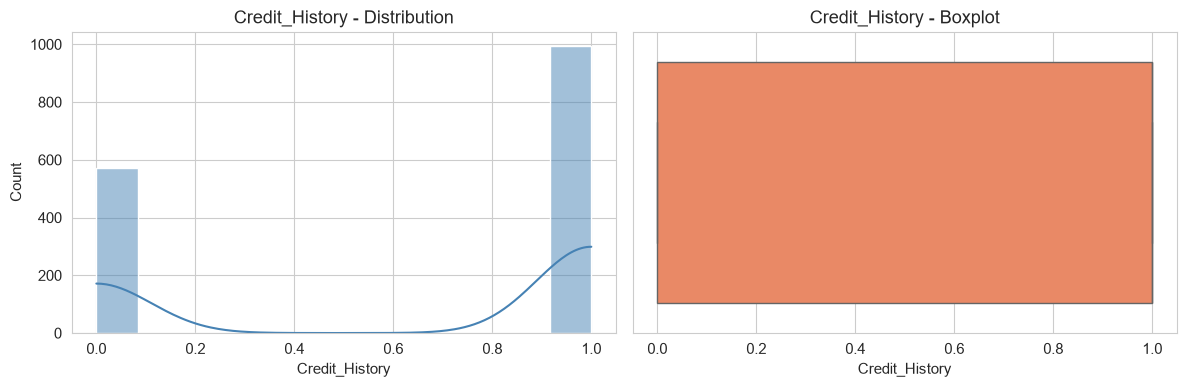

In [18]:
print('--- Credit_History ---')
print(loan_df['Credit_History'].describe())
print(f"Skewness: {loan_df['Credit_History'].skew():.2f}")
print(f"Missing: {loan_df['Credit_History'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['Credit_History'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Credit_History - Distribution')
sns.boxplot(x=loan_df['Credit_History'], ax=axes[1], color='coral')
axes[1].set_title('Credit_History - Boxplot')
plt.tight_layout()
plt.show()


### `Property_Area`

Property area (Urban/Semiurban/Rural).


--- Property_Area ---
Unique values: 3
Missing: 0
Property_Area
Urban        549
Semiurban    545
Rural        520
Name: count, dtype: int64


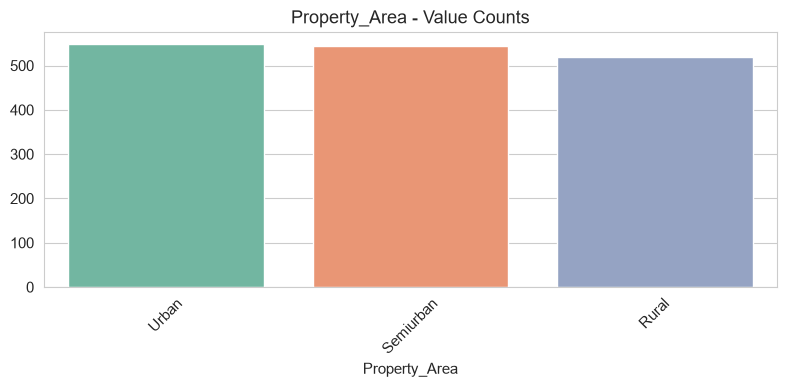

In [19]:
print('--- Property_Area ---')
print(f"Unique values: {loan_df['Property_Area'].nunique()}")
print(f"Missing: {loan_df['Property_Area'].isnull().sum()}")
print(loan_df['Property_Area'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Property_Area'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Property_Area - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Loan_Status`

Target variable - loan approved (Y) or not (N).


--- Loan_Status ---
Unique values: 2
Missing: 0
Loan_Status
Y    915
N    699
Name: count, dtype: int64


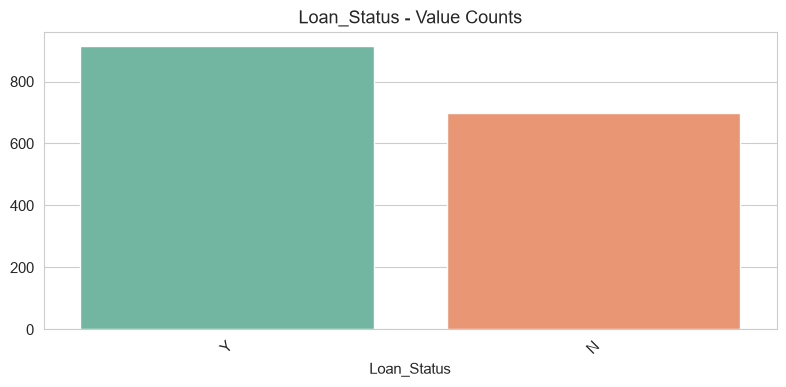

In [20]:
print('--- Loan_Status ---')
print(f"Unique values: {loan_df['Loan_Status'].nunique()}")
print(f"Missing: {loan_df['Loan_Status'].isnull().sum()}")
print(loan_df['Loan_Status'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Loan_Status'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Loan_Status - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Correlation Analysis (Numerical Columns)


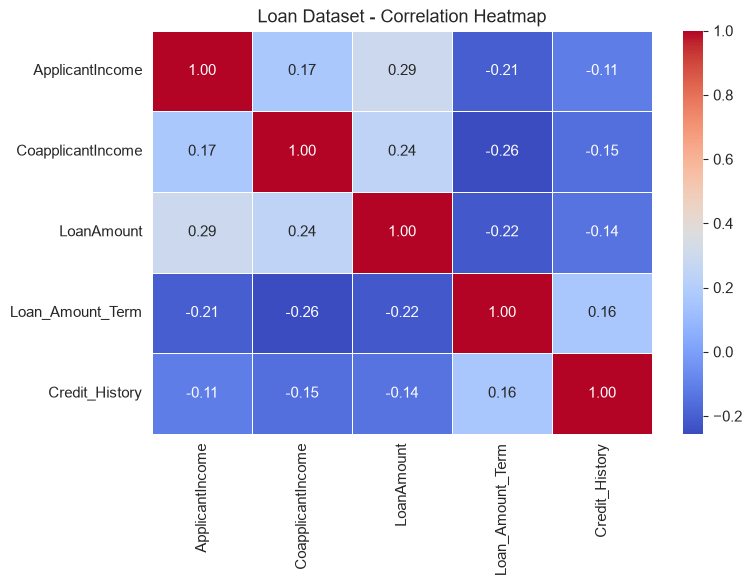

In [21]:
num_cols_loan = loan_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(loan_df[num_cols_loan].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Loan Dataset - Correlation Heatmap')
plt.tight_layout()
plt.show()


## Target Variable Analysis: `Loan_Status`


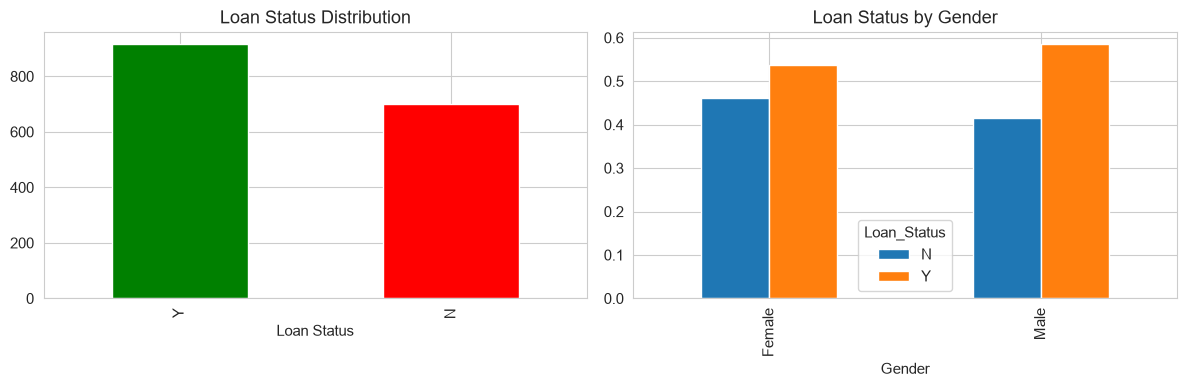

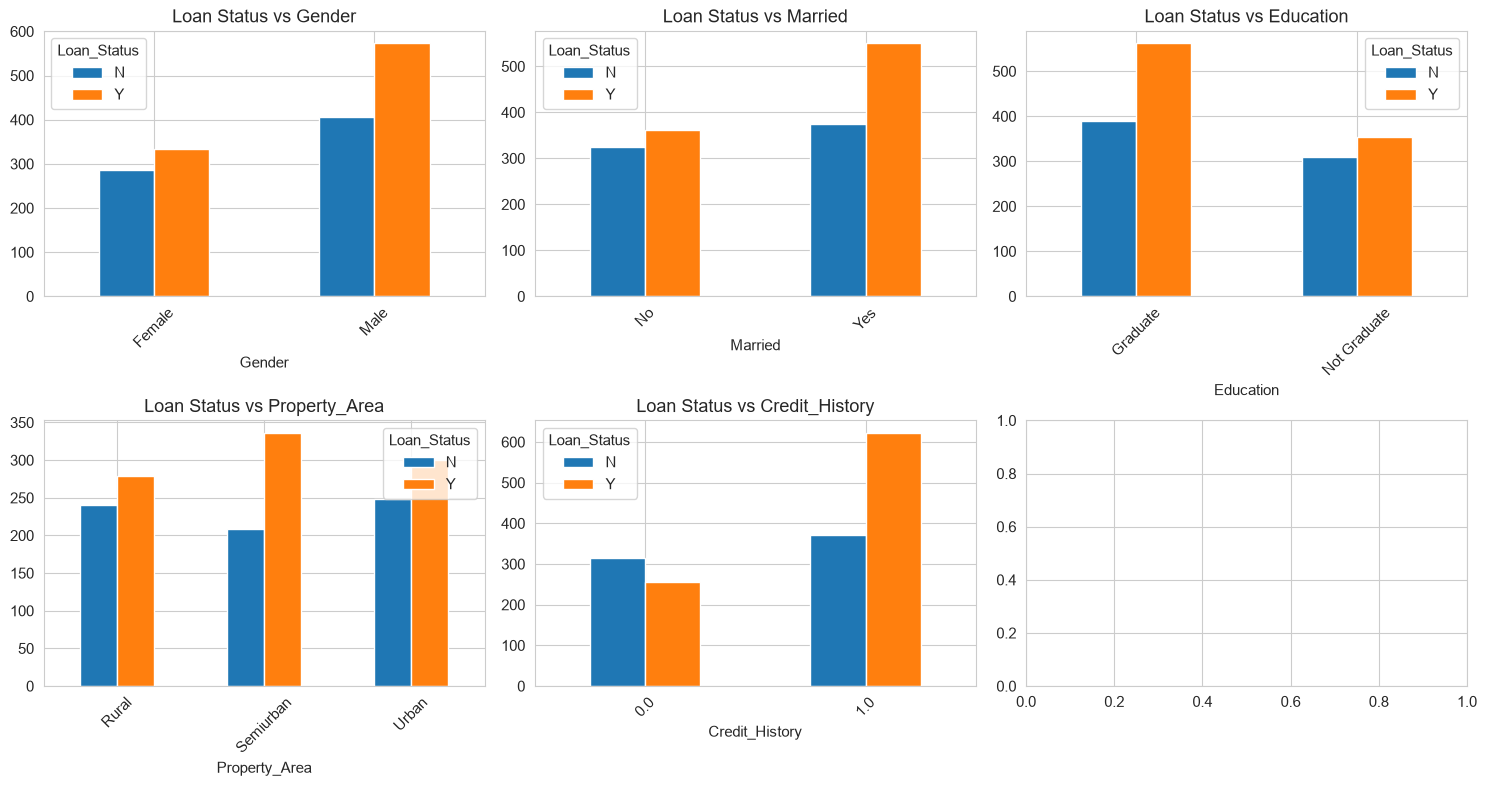

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
loan_df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Loan Status Distribution')
axes[0].set_xlabel('Loan Status')

cat_cols_loan = ['Gender', 'Married', 'Education', 'Property_Area', 'Credit_History']
for i, col in enumerate(cat_cols_loan[:1]):
    pd.crosstab(loan_df[col], loan_df['Loan_Status'], normalize='index').plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'Loan Status by {cat_cols_loan[0]}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols_loan):
    pd.crosstab(loan_df[col], loan_df['Loan_Status']).plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Loan Status vs {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Data Cleaning - Loan Dataset

Cleaning steps:
1. Drop `Loan_ID` (identifier, not useful for analysis)
2. Impute missing categorical values with mode
3. Impute missing numerical values with median
4. Convert `Dependents` '3+' to numeric 3
5. Ensure correct data types


In [23]:
loan_clean = loan_df.copy()

# Drop Loan_ID
loan_clean = loan_clean.drop('Loan_ID', axis=1)

# Convert Dependents '3+' to 3
loan_clean['Dependents'] = loan_clean['Dependents'].replace('3+', '3')
loan_clean['Dependents'] = pd.to_numeric(loan_clean['Dependents'], errors='coerce')

# Impute categorical columns with mode
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
for col in cat_cols:
    mode_val = loan_clean[col].mode()[0]
    loan_clean[col] = loan_clean[col].fillna(mode_val)
    print(f'{col}: filled with mode = {mode_val}')

# Impute numerical columns with median
num_cols = ['Dependents', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols:
    median_val = loan_clean[col].median()
    loan_clean[col] = loan_clean[col].fillna(median_val)
    print(f'{col}: filled with median = {median_val}')

print('\nMissing values after cleaning:')
print(loan_clean.isnull().sum().sum())


Gender: filled with mode = Male
Married: filled with mode = Yes
Education: filled with mode = Graduate
Self_Employed: filled with mode = No
Property_Area: filled with mode = Urban
Dependents: filled with median = 1.0
LoanAmount: filled with median = 180.0
Loan_Amount_Term: filled with median = 360.0
Credit_History: filled with median = 1.0

Missing values after cleaning:
0


In [24]:
print('Before cleaning shape:', loan_original.shape)
print('After cleaning shape:', loan_clean.shape)
print('\nCleaned dataset info:')
loan_clean.info()
loan_clean.head()


Before cleaning shape: (1614, 13)
After cleaning shape: (1614, 12)

Cleaned dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             1614 non-null   str    
 1   Married            1614 non-null   str    
 2   Dependents         1614 non-null   float64
 3   Education          1614 non-null   str    
 4   Self_Employed      1614 non-null   str    
 5   ApplicantIncome    1614 non-null   int64  
 6   CoapplicantIncome  1614 non-null   float64
 7   LoanAmount         1614 non-null   float64
 8   Loan_Amount_Term   1614 non-null   float64
 9   Credit_History     1614 non-null   float64
 10  Property_Area      1614 non-null   str    
 11  Loan_Status        1614 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 151.4 KB


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,180.0,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
print('--- Before vs After Missing Values ---')
comparison = pd.DataFrame({
    'Before': loan_original.drop('Loan_ID', axis=1).isnull().sum(),
    'After': loan_clean.isnull().sum()
})
comparison[comparison['Before'] > 0]


--- Before vs After Missing Values ---


,Before,After
Gender,13,0
Married,3,0
Dependents,15,0
Self_Employed,32,0
LoanAmount,22,0
Loan_Amount_Term,14,0
Credit_History,50,0


---
# Dataset 2: Adult Census Income

Loading the Adult dataset and performing complete EDA and data cleaning.


In [26]:
adult_df = pd.read_csv('adult.csv')
adult_original = adult_df.copy()
print('Shape:', adult_df.shape)
adult_df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [27]:
adult_df.info()
print('\n--- Data Types ---')
print(adult_df.dtypes)
print('\n--- Statistical Summary (Numerical) ---')
adult_df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB

--- Data Types ---
age                int64
workclass            str
fnlwgt             int64
education    

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [28]:
print('--- Statistical Summary (Categorical) ---')
adult_df.describe(include='object')


--- Statistical Summary (Categorical) ---


,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


## Missing Values Analysis

Note: Missing values are encoded as `'?'` in this dataset.


In [29]:
# Replace '?' with NaN for proper missing value analysis
adult_df_temp = adult_df.replace('?', np.nan)
missing_adult = adult_df_temp.isnull().sum()
missing_pct_adult = (missing_adult / len(adult_df) * 100).round(2)
missing_df_adult = pd.DataFrame({'Missing Count': missing_adult, 'Missing %': missing_pct_adult})
missing_df_adult[missing_df_adult['Missing Count'] > 0]


,Missing Count,Missing %
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


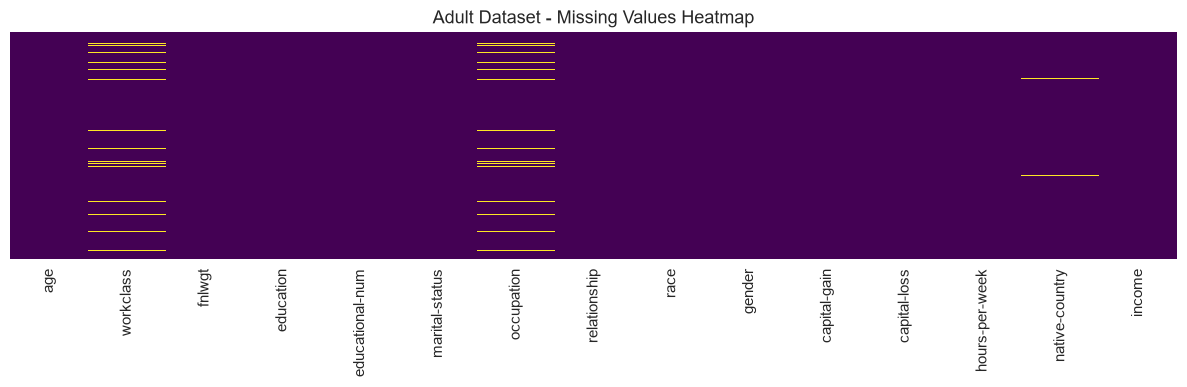

In [30]:
plt.figure(figsize=(12, 4))
sns.heatmap(adult_df_temp.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Adult Dataset - Missing Values Heatmap')
plt.tight_layout()
plt.show()


## Duplicate Records


In [31]:
print('Duplicate rows:', adult_df.duplicated().sum())
adult_df[adult_df.duplicated(keep=False)].head(10)


Duplicate rows: 52


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
488,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
864,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
1319,37,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
1668,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
1854,22,Private,137876,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,20,United-States,<=50K
1863,20,?,203353,Some-college,10,Never-married,?,Own-child,White,Female,0,0,40,United-States,<=50K
3900,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
4152,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
5078,29,?,41281,Bachelors,13,Married-spouse-absent,?,Not-in-family,White,Male,0,0,50,United-States,<=50K
5782,21,Private,301694,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,35,Mexico,<=50K


## Column-wise Analysis

Analyzing every column individually.


### `age`

Age of the individual.


--- age ---
count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64
Skewness: 0.56


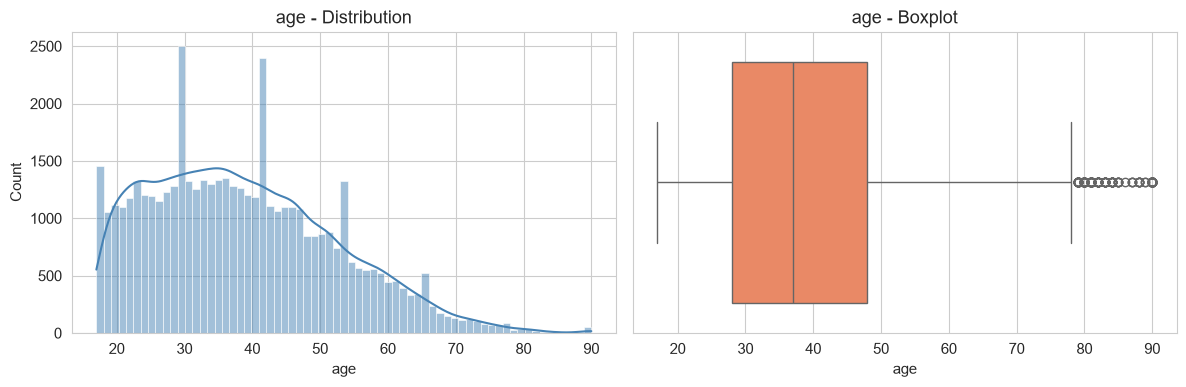

In [32]:
print('--- age ---')
print(adult_df['age'].describe())
print(f"Skewness: {adult_df['age'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('age - Distribution')
sns.boxplot(x=adult_df['age'], ax=axes[1], color='coral')
axes[1].set_title('age - Boxplot')
plt.tight_layout()
plt.show()


### `workclass`

Type of employer (Private, Self-emp, Gov, etc.).


--- workclass ---
Unique values: 9
Missing (?): 2799
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


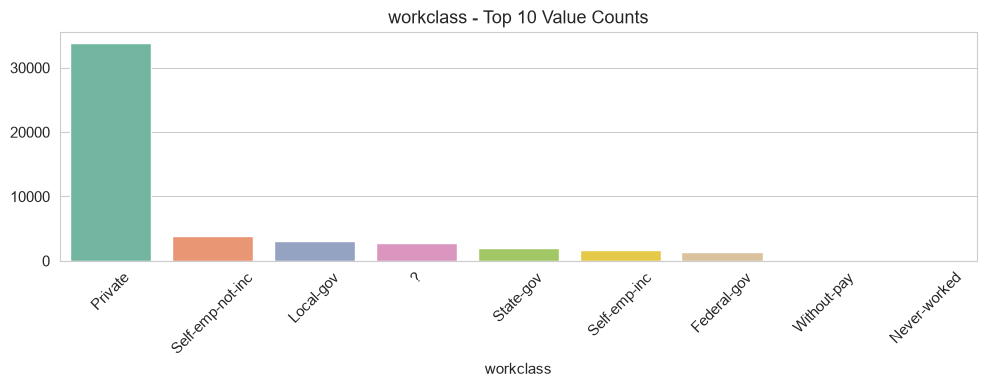

In [33]:
print('--- workclass ---')
print(f"Unique values: {adult_df['workclass'].nunique()}")
print(f"Missing (?): {(adult_df['workclass'] == '?').sum()}")
print(adult_df['workclass'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['workclass'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('workclass - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `fnlwgt`

Final weight - sampling weight from census.


--- fnlwgt ---
count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64
Skewness: 1.44


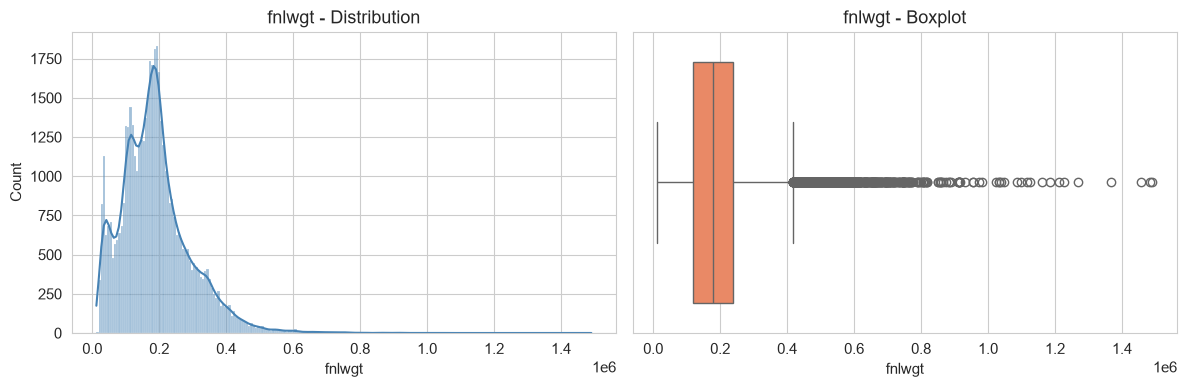

In [34]:
print('--- fnlwgt ---')
print(adult_df['fnlwgt'].describe())
print(f"Skewness: {adult_df['fnlwgt'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['fnlwgt'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('fnlwgt - Distribution')
sns.boxplot(x=adult_df['fnlwgt'], ax=axes[1], color='coral')
axes[1].set_title('fnlwgt - Boxplot')
plt.tight_layout()
plt.show()


### `education`

Highest education level attained.


--- education ---
Unique values: 16
Missing (?): 0
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64


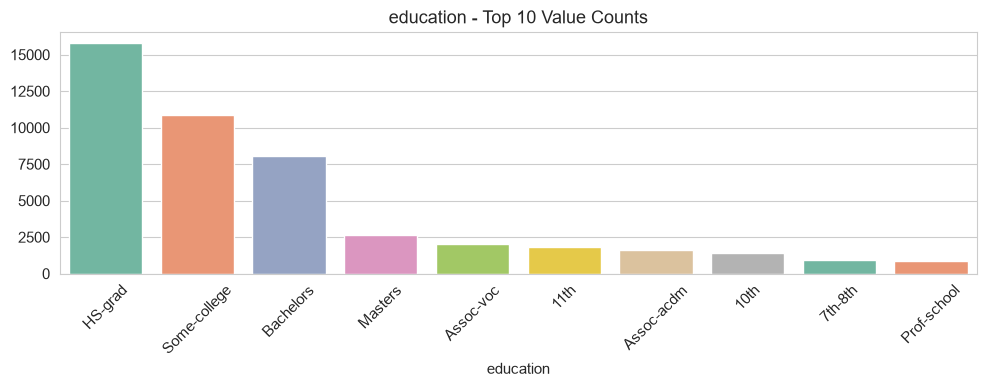

In [35]:
print('--- education ---')
print(f"Unique values: {adult_df['education'].nunique()}")
print(f"Missing (?): {(adult_df['education'] == '?').sum()}")
print(adult_df['education'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['education'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('education - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `educational-num`

Numeric encoding of education level.


--- educational-num ---
count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: educational-num, dtype: float64
Skewness: -0.32


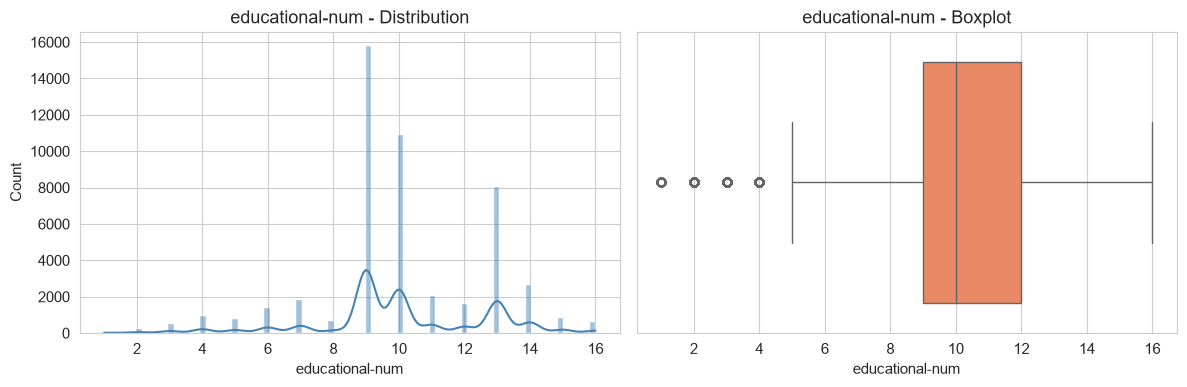

In [36]:
print('--- educational-num ---')
print(adult_df['educational-num'].describe())
print(f"Skewness: {adult_df['educational-num'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['educational-num'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('educational-num - Distribution')
sns.boxplot(x=adult_df['educational-num'], ax=axes[1], color='coral')
axes[1].set_title('educational-num - Boxplot')
plt.tight_layout()
plt.show()


### `marital-status`

Marital status of the individual.


--- marital-status ---
Unique values: 7
Missing (?): 0
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64


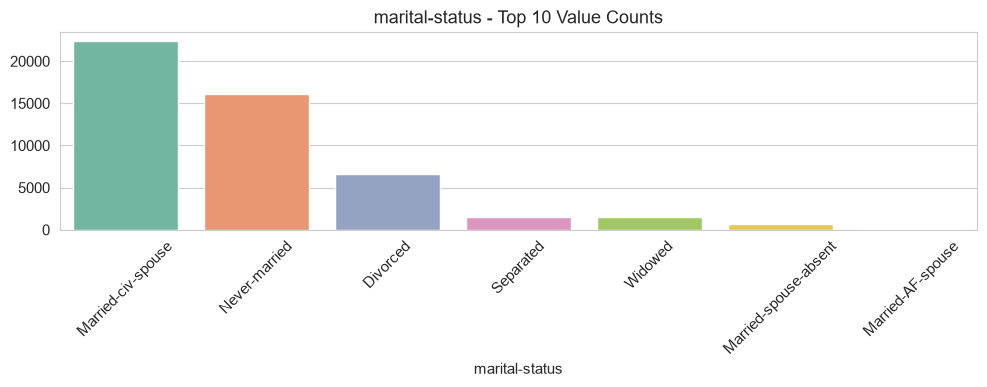

In [37]:
print('--- marital-status ---')
print(f"Unique values: {adult_df['marital-status'].nunique()}")
print(f"Missing (?): {(adult_df['marital-status'] == '?').sum()}")
print(adult_df['marital-status'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['marital-status'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('marital-status - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `occupation`

Type of occupation.


--- occupation ---
Unique values: 15
Missing (?): 2809
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
?                    2809
Transport-moving     2355
Handlers-cleaners    2072
Name: count, dtype: int64


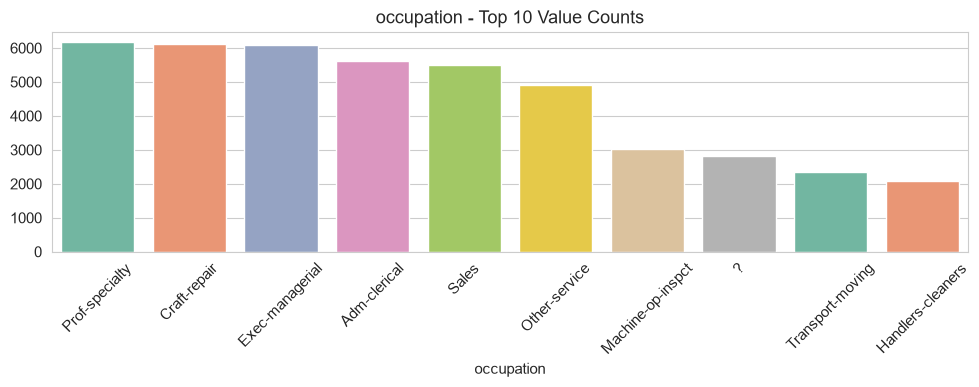

In [38]:
print('--- occupation ---')
print(f"Unique values: {adult_df['occupation'].nunique()}")
print(f"Missing (?): {(adult_df['occupation'] == '?').sum()}")
print(adult_df['occupation'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['occupation'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('occupation - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `relationship`

Relationship status in household.


--- relationship ---
Unique values: 6
Missing (?): 0
relationship
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64


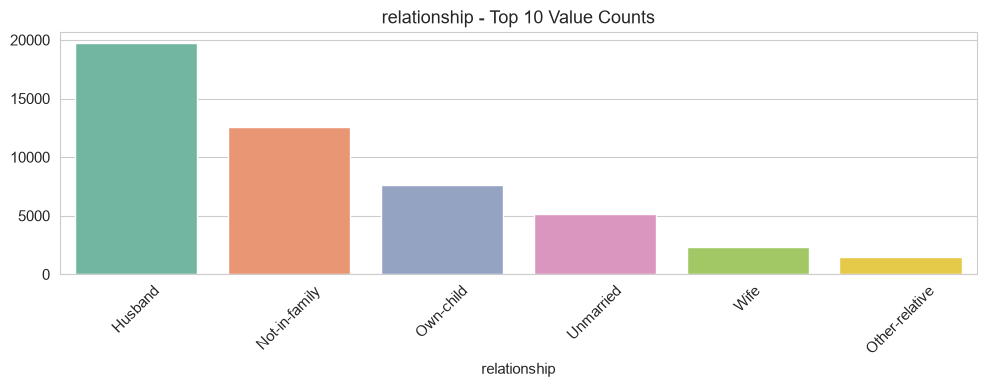

In [39]:
print('--- relationship ---')
print(f"Unique values: {adult_df['relationship'].nunique()}")
print(f"Missing (?): {(adult_df['relationship'] == '?').sum()}")
print(adult_df['relationship'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['relationship'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('relationship - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `race`

Race of the individual.


--- race ---
Unique values: 5
Missing (?): 0
race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64


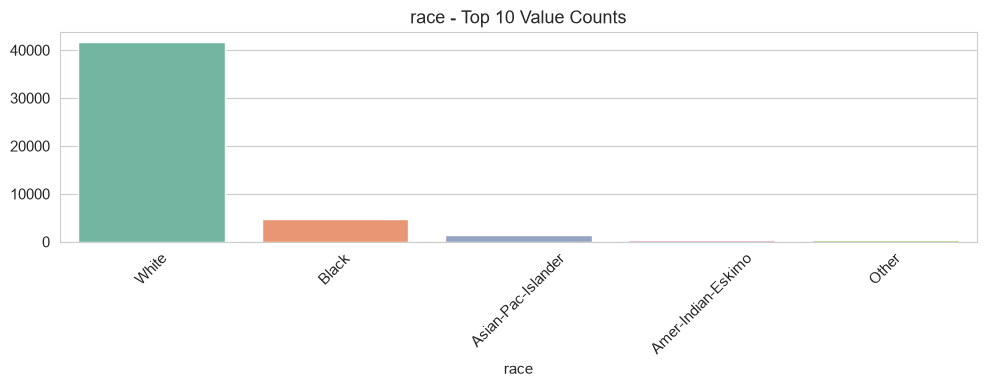

In [40]:
print('--- race ---')
print(f"Unique values: {adult_df['race'].nunique()}")
print(f"Missing (?): {(adult_df['race'] == '?').sum()}")
print(adult_df['race'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['race'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('race - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `gender`

Gender of the individual.


--- gender ---
Unique values: 2
Missing (?): 0
gender
Male      32650
Female    16192
Name: count, dtype: int64


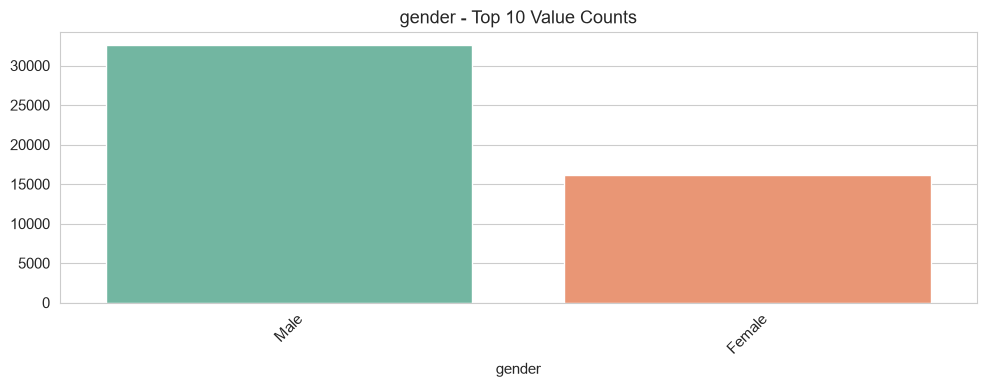

In [41]:
print('--- gender ---')
print(f"Unique values: {adult_df['gender'].nunique()}")
print(f"Missing (?): {(adult_df['gender'] == '?').sum()}")
print(adult_df['gender'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['gender'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('gender - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `capital-gain`

Capital gains income.


--- capital-gain ---
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64
Skewness: 11.89


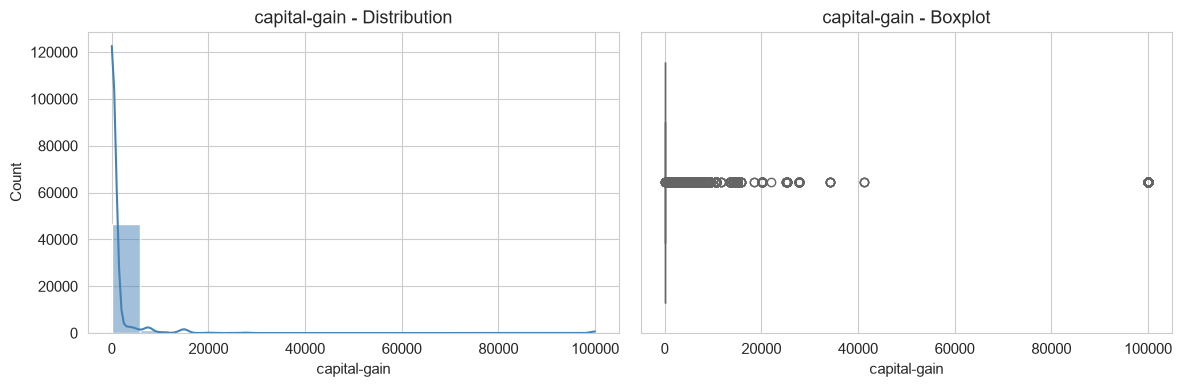

In [42]:
print('--- capital-gain ---')
print(adult_df['capital-gain'].describe())
print(f"Skewness: {adult_df['capital-gain'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['capital-gain'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('capital-gain - Distribution')
sns.boxplot(x=adult_df['capital-gain'], ax=axes[1], color='coral')
axes[1].set_title('capital-gain - Boxplot')
plt.tight_layout()
plt.show()


### `capital-loss`

Capital losses.


--- capital-loss ---
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64
Skewness: 4.57


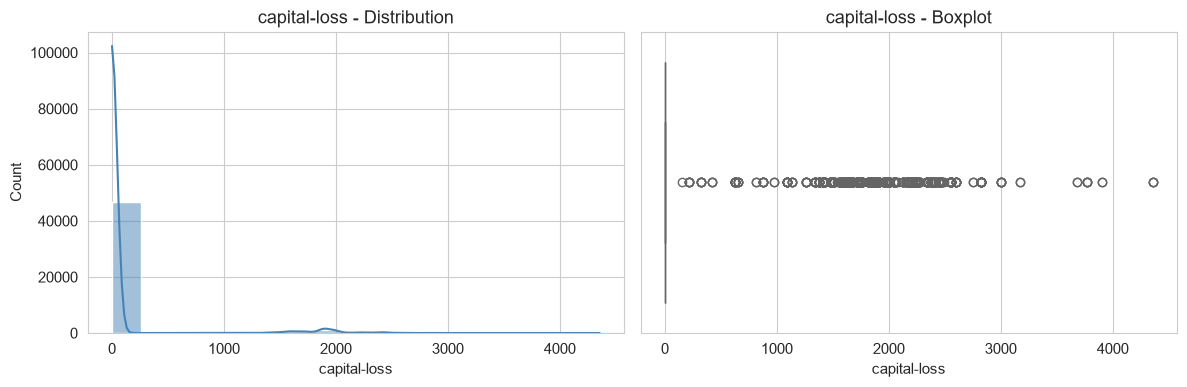

In [43]:
print('--- capital-loss ---')
print(adult_df['capital-loss'].describe())
print(f"Skewness: {adult_df['capital-loss'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['capital-loss'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('capital-loss - Distribution')
sns.boxplot(x=adult_df['capital-loss'], ax=axes[1], color='coral')
axes[1].set_title('capital-loss - Boxplot')
plt.tight_layout()
plt.show()


### `hours-per-week`

Hours worked per week.


--- hours-per-week ---
count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64
Skewness: 0.24


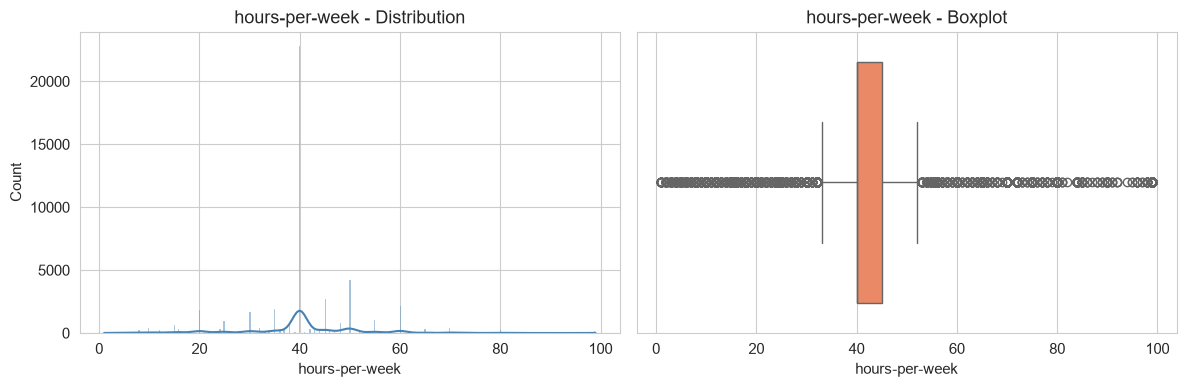

In [44]:
print('--- hours-per-week ---')
print(adult_df['hours-per-week'].describe())
print(f"Skewness: {adult_df['hours-per-week'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['hours-per-week'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('hours-per-week - Distribution')
sns.boxplot(x=adult_df['hours-per-week'], ax=axes[1], color='coral')
axes[1].set_title('hours-per-week - Boxplot')
plt.tight_layout()
plt.show()


### `native-country`

Country of origin.


--- native-country ---
Unique values: 42
Missing (?): 857
native-country
United-States    43832
Mexico             951
?                  857
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Cuba               138
Name: count, dtype: int64


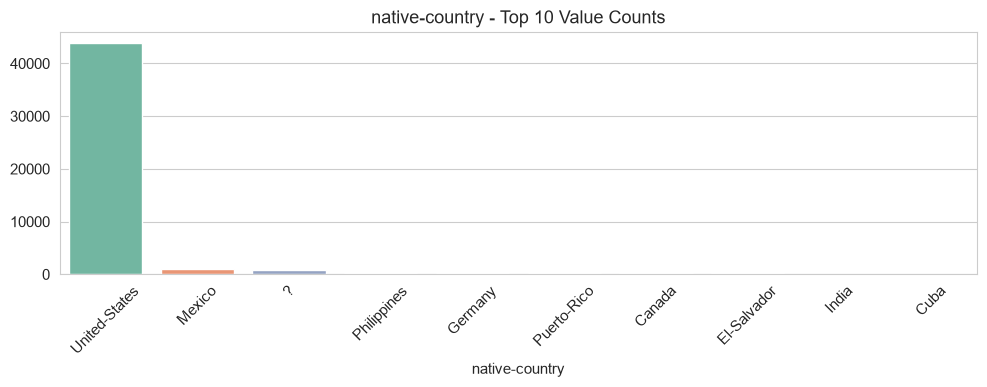

In [45]:
print('--- native-country ---')
print(f"Unique values: {adult_df['native-country'].nunique()}")
print(f"Missing (?): {(adult_df['native-country'] == '?').sum()}")
print(adult_df['native-country'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['native-country'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('native-country - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `income`

Target variable - income <=50K or >50K.


--- income ---
Unique values: 2
Missing (?): 0
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


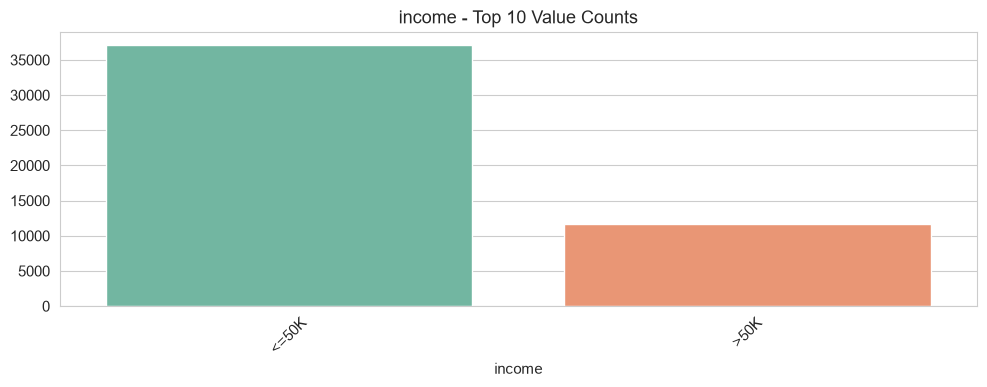

In [46]:
print('--- income ---')
print(f"Unique values: {adult_df['income'].nunique()}")
print(f"Missing (?): {(adult_df['income'] == '?').sum()}")
print(adult_df['income'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['income'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('income - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Correlation Analysis (Numerical Columns)


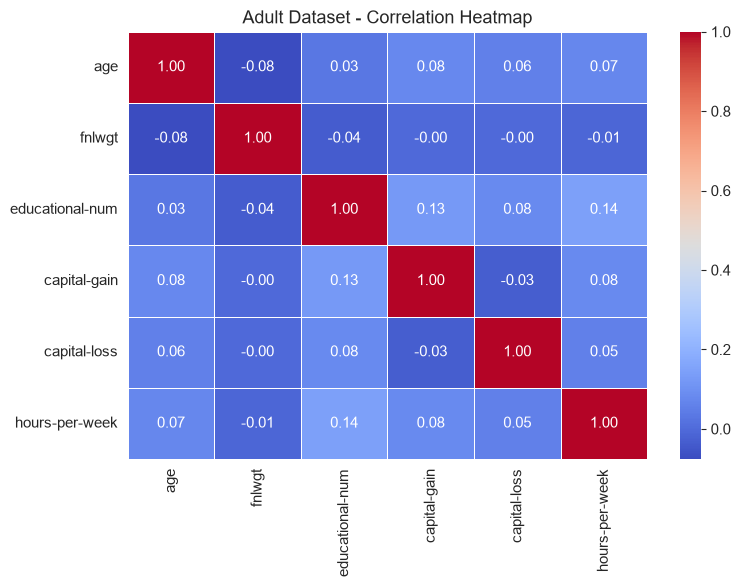

In [47]:
num_cols_adult = adult_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(adult_df[num_cols_adult].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Adult Dataset - Correlation Heatmap')
plt.tight_layout()
plt.show()


## Target Variable Analysis: `income`


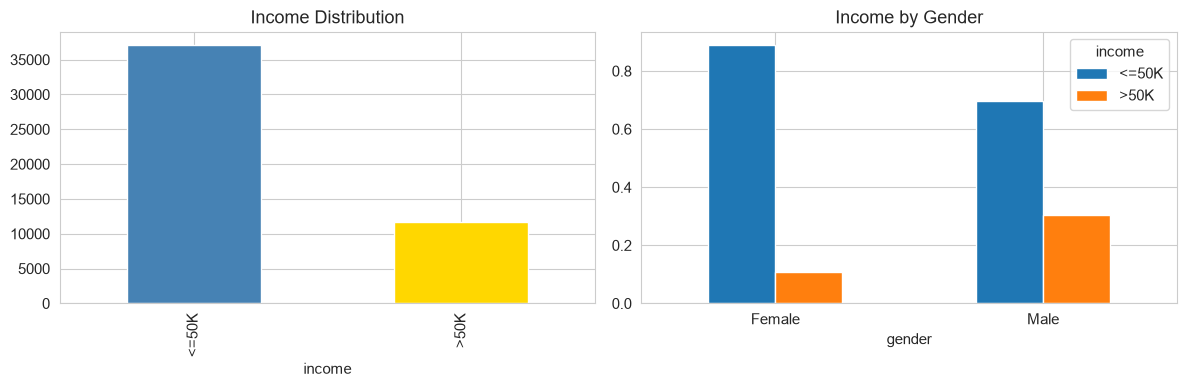

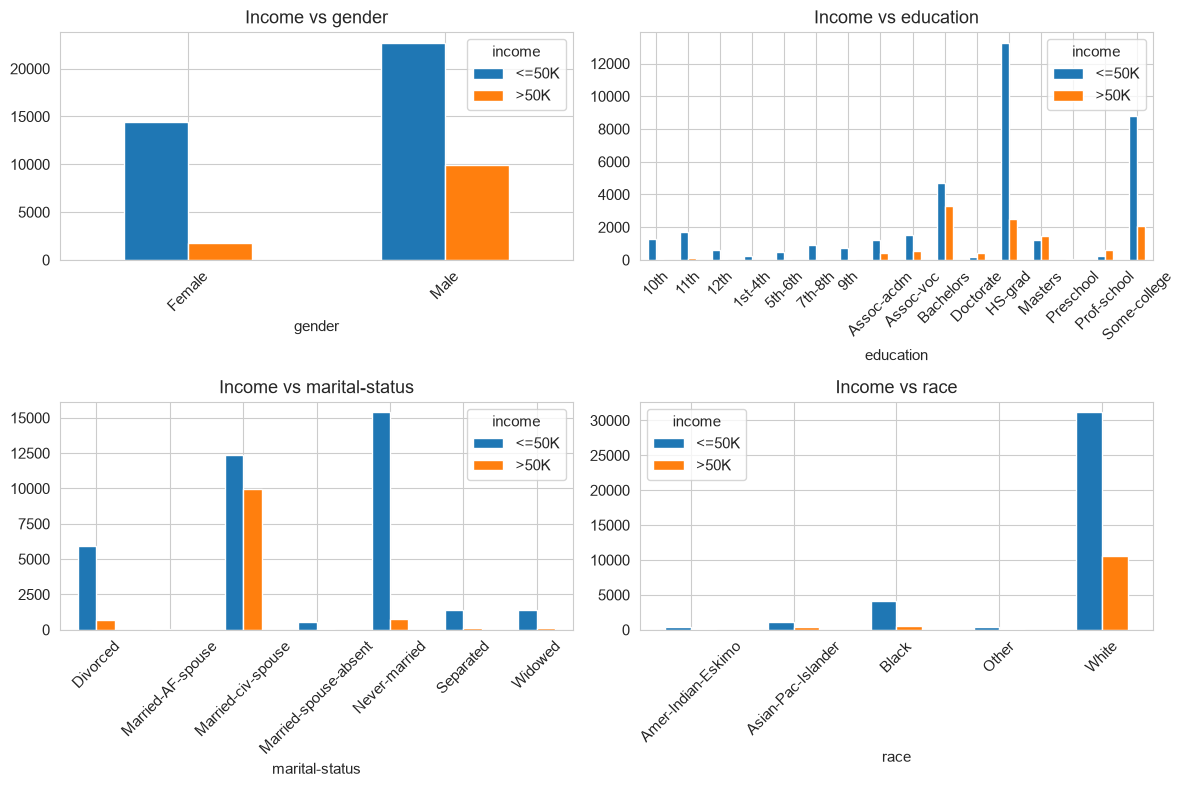

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
adult_df['income'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'gold'])
axes[0].set_title('Income Distribution')

for col in ['gender', 'education']:
    pass
pd.crosstab(adult_df['gender'], adult_df['income'], normalize='index').plot(kind='bar', ax=axes[1])
axes[1].set_title('Income by Gender')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(['gender', 'education', 'marital-status', 'race']):
    pd.crosstab(adult_df[col], adult_df['income']).plot(kind='bar', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Income vs {col}')
    axes[i//2, i%2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Data Cleaning - Adult Dataset

Cleaning steps:
1. Replace `'?'` with NaN
2. Remove duplicate rows
3. Impute missing categorical values with mode
4. Drop `fnlwgt` (sampling weight, not useful for analysis)
5. Remove invalid age values if any


In [49]:
adult_clean = adult_df.copy()

# Replace '?' with NaN
adult_clean = adult_clean.replace('?', np.nan)

# Remove duplicates
before_dup = len(adult_clean)
adult_clean = adult_clean.drop_duplicates()
print(f'Removed {before_dup - len(adult_clean)} duplicate rows')

# Impute missing categorical columns with mode
cat_cols_adult = ['workclass', 'occupation', 'native-country']
for col in cat_cols_adult:
    mode_val = adult_clean[col].mode()[0]
    adult_clean[col] = adult_clean[col].fillna(mode_val)
    print(f'{col}: filled with mode = {mode_val}')

# Drop fnlwgt (census sampling weight)
adult_clean = adult_clean.drop('fnlwgt', axis=1)

# Validate age range
print(f'\nAge range: {adult_clean["age"].min()} - {adult_clean["age"].max()}')
adult_clean = adult_clean[(adult_clean['age'] >= 17) & (adult_clean['age'] <= 90)]

print('\nMissing values after cleaning:')
print(adult_clean.isnull().sum().sum())


Removed 52 duplicate rows
workclass: filled with mode = Private
occupation: filled with mode = Prof-specialty
native-country: filled with mode = United-States

Age range: 17 - 90

Missing values after cleaning:
0


In [50]:
print('Before cleaning shape:', adult_original.shape)
print('After cleaning shape:', adult_clean.shape)
print('\nCleaned dataset info:')
adult_clean.info()
adult_clean.head()


Before cleaning shape: (48842, 15)
After cleaning shape: (48790, 14)

Cleaned dataset info:
<class 'pandas.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48790 non-null  int64
 1   workclass        48790 non-null  str  
 2   education        48790 non-null  str  
 3   educational-num  48790 non-null  int64
 4   marital-status   48790 non-null  str  
 5   occupation       48790 non-null  str  
 6   relationship     48790 non-null  str  
 7   race             48790 non-null  str  
 8   gender           48790 non-null  str  
 9   capital-gain     48790 non-null  int64
 10  capital-loss     48790 non-null  int64
 11  hours-per-week   48790 non-null  int64
 12  native-country   48790 non-null  str  
 13  income           48790 non-null  str  
dtypes: int64(5), str(9)
memory usage: 5.6 MB


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


In [51]:
print('--- Before vs After ---')
print(f'Duplicates removed: {adult_original.duplicated().sum()}')
print(f'Missing (?) before: {(adult_original == "?").sum().sum()}')
print(f'Missing after: {adult_clean.isnull().sum().sum()}')


--- Before vs After ---


Duplicates removed: 52

Missing (?) before: 6465
Missing after: 0


---
# Dataset 3: Hotel Booking

Loading the Hotel Booking dataset and performing complete EDA and data cleaning.


In [52]:
hotel_df = pd.read_csv('hotel_booking.csv')
hotel_original = hotel_df.copy()
print('Shape:', hotel_df.shape)
hotel_df.head()


Shape: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [53]:
hotel_df.info()
print('\n--- Data Types ---')
print(hotel_df.dtypes)
print('\n--- Statistical Summary (Numerical) ---')
hotel_df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [54]:
print('--- Statistical Summary (Categorical) ---')
hotel_df.describe(include='object')


--- Statistical Summary (Categorical) ---


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926,81503,115889,119390,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,669-792-1661,************3627
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461,48,6,1,28


## Missing Values Analysis


In [55]:
missing_hotel = hotel_df.isnull().sum()
missing_pct_hotel = (missing_hotel / len(hotel_df) * 100).round(2)
missing_df_hotel = pd.DataFrame({'Missing Count': missing_hotel, 'Missing %': missing_pct_hotel})
missing_df_hotel[missing_df_hotel['Missing Count'] > 0].sort_values('Missing Count', ascending=False)


,Missing Count,Missing %
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


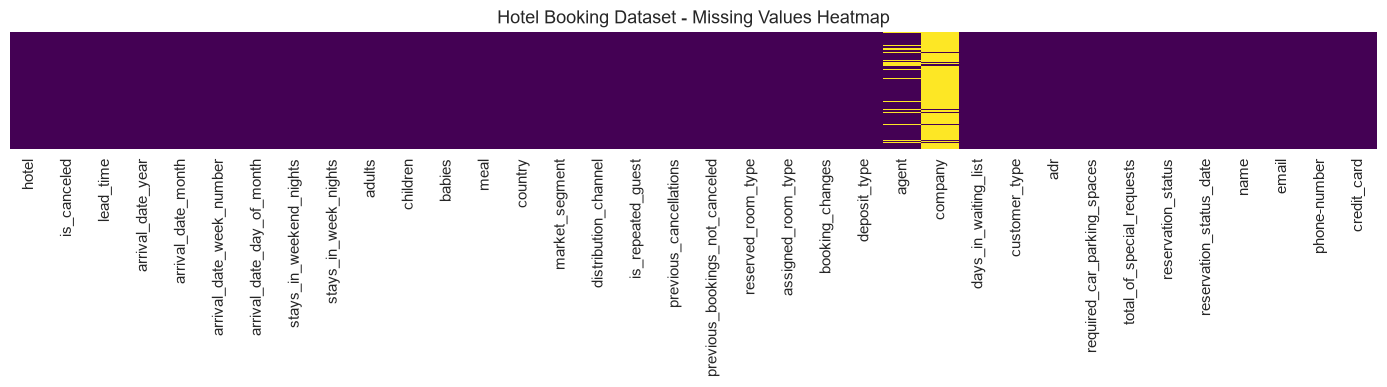

In [56]:
plt.figure(figsize=(14, 4))
sns.heatmap(hotel_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Hotel Booking Dataset - Missing Values Heatmap')
plt.tight_layout()
plt.show()


## Duplicate Records


In [57]:
print('Duplicate rows:', hotel_df.duplicated().sum())


Duplicate rows: 0


## Column-wise Analysis

Analyzing every column individually.


### `hotel`

Type of hotel (Resort Hotel or City Hotel).


--- hotel ---
Unique values: 2
Missing: 0
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


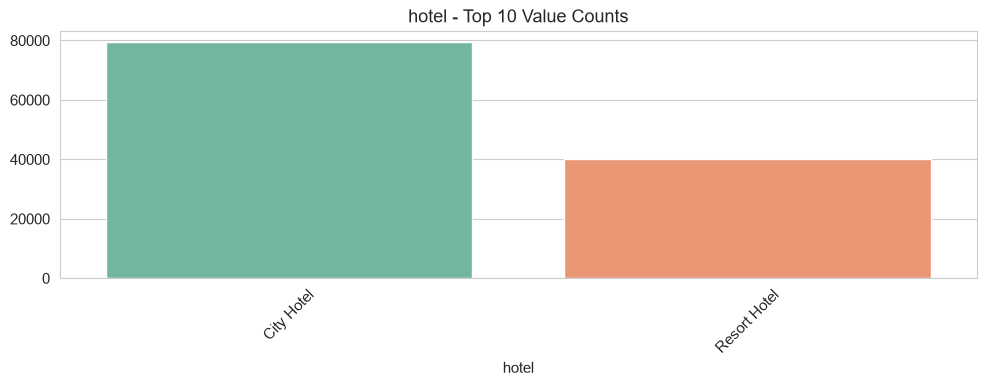

In [58]:
print('--- hotel ---')
print(f"Unique values: {hotel_df['hotel'].nunique()}")
print(f"Missing: {hotel_df['hotel'].isnull().sum()}")
print(hotel_df['hotel'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['hotel'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('hotel - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `is_canceled`

Target - whether booking was canceled (0=No, 1=Yes).


--- is_canceled ---
count    119390.000000
mean          0.370416
std           0.482918
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: is_canceled, dtype: float64
Missing: 0
Skewness: 0.54


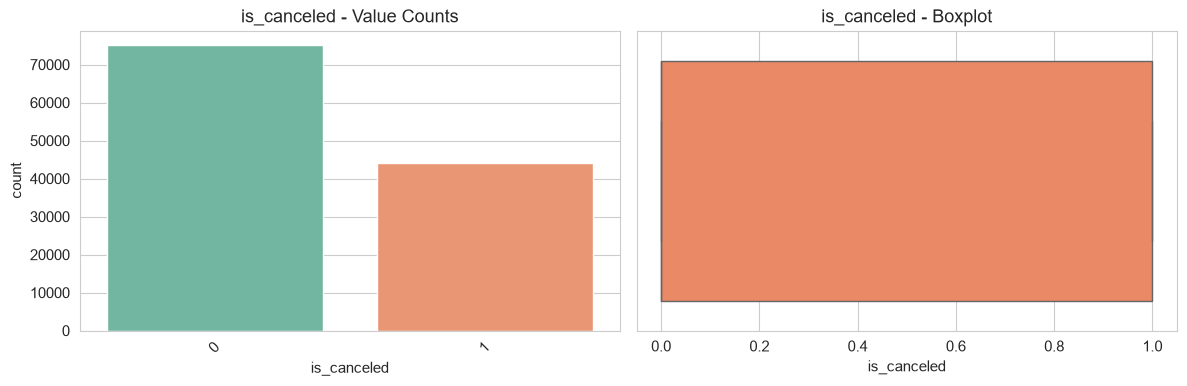

In [59]:
print('--- is_canceled ---')
print(hotel_df['is_canceled'].describe())
print(f"Missing: {hotel_df['is_canceled'].isnull().sum()}")
if hotel_df['is_canceled'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['is_canceled'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['is_canceled'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['is_canceled'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('is_canceled - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('is_canceled - Distribution')
sns.boxplot(x=hotel_df['is_canceled'], ax=axes[1], color='coral')
axes[1].set_title('is_canceled - Boxplot')
plt.tight_layout()
plt.show()


### `lead_time`

Days between booking and arrival.


--- lead_time ---
count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64
Missing: 0
Skewness: 1.35


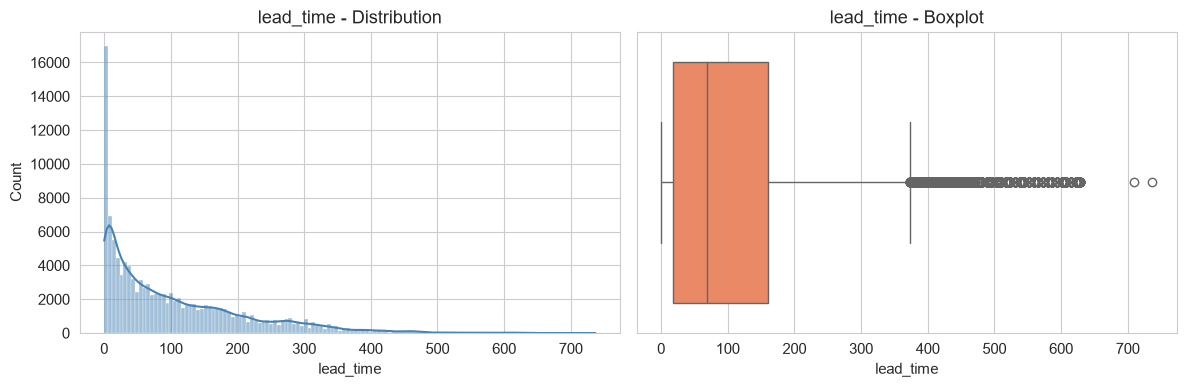

In [60]:
print('--- lead_time ---')
print(hotel_df['lead_time'].describe())
print(f"Missing: {hotel_df['lead_time'].isnull().sum()}")
if hotel_df['lead_time'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['lead_time'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['lead_time'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['lead_time'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('lead_time - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('lead_time - Distribution')
sns.boxplot(x=hotel_df['lead_time'], ax=axes[1], color='coral')
axes[1].set_title('lead_time - Boxplot')
plt.tight_layout()
plt.show()


### `arrival_date_year`

Year of arrival date.


--- arrival_date_year ---
count    119390.000000
mean       2016.156554
std           0.707476
min        2015.000000
25%        2016.000000
50%        2016.000000
75%        2017.000000
max        2017.000000
Name: arrival_date_year, dtype: float64
Missing: 0
Skewness: -0.23


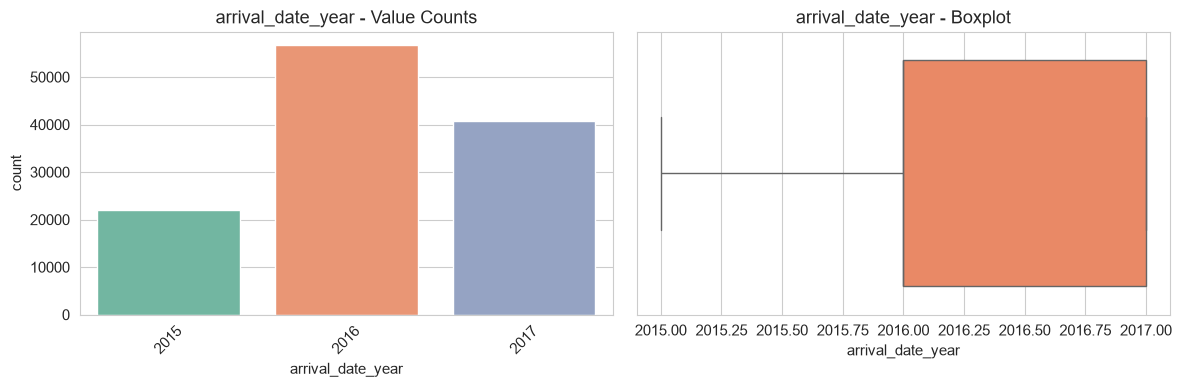

In [61]:
print('--- arrival_date_year ---')
print(hotel_df['arrival_date_year'].describe())
print(f"Missing: {hotel_df['arrival_date_year'].isnull().sum()}")
if hotel_df['arrival_date_year'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['arrival_date_year'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['arrival_date_year'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['arrival_date_year'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('arrival_date_year - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('arrival_date_year - Distribution')
sns.boxplot(x=hotel_df['arrival_date_year'], ax=axes[1], color='coral')
axes[1].set_title('arrival_date_year - Boxplot')
plt.tight_layout()
plt.show()


### `arrival_date_month`

Month of arrival.


--- arrival_date_month ---
Unique values: 12
Missing: 0
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
Name: count, dtype: int64


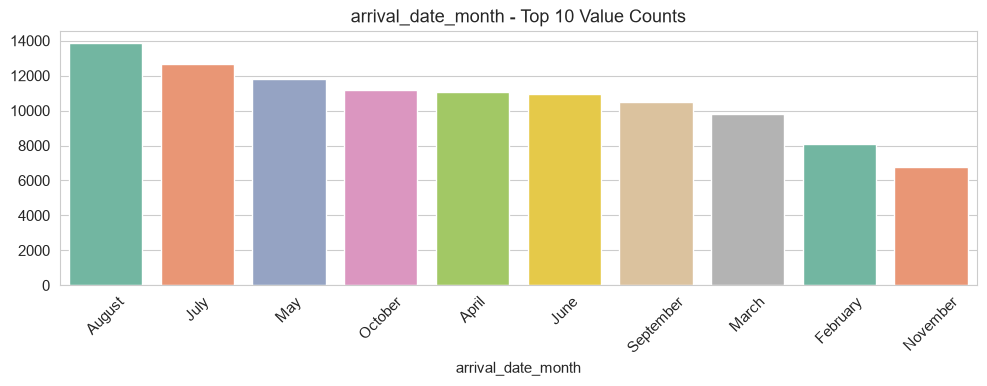

In [62]:
print('--- arrival_date_month ---')
print(f"Unique values: {hotel_df['arrival_date_month'].nunique()}")
print(f"Missing: {hotel_df['arrival_date_month'].isnull().sum()}")
print(hotel_df['arrival_date_month'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['arrival_date_month'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('arrival_date_month - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `arrival_date_week_number`

Week number of arrival date.


--- arrival_date_week_number ---
count    119390.000000
mean         27.165173
std          13.605138
min           1.000000
25%          16.000000
50%          28.000000
75%          38.000000
max          53.000000
Name: arrival_date_week_number, dtype: float64
Missing: 0
Skewness: -0.01


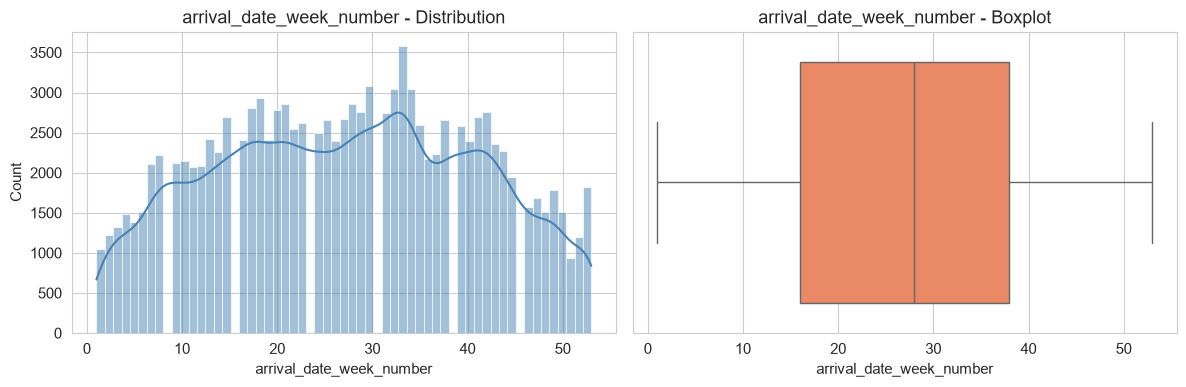

In [63]:
print('--- arrival_date_week_number ---')
print(hotel_df['arrival_date_week_number'].describe())
print(f"Missing: {hotel_df['arrival_date_week_number'].isnull().sum()}")
if hotel_df['arrival_date_week_number'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['arrival_date_week_number'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['arrival_date_week_number'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['arrival_date_week_number'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('arrival_date_week_number - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('arrival_date_week_number - Distribution')
sns.boxplot(x=hotel_df['arrival_date_week_number'], ax=axes[1], color='coral')
axes[1].set_title('arrival_date_week_number - Boxplot')
plt.tight_layout()
plt.show()


### `arrival_date_day_of_month`

Day of the month of arrival.


--- arrival_date_day_of_month ---
count    119390.000000
mean         15.798241
std           8.780829
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: arrival_date_day_of_month, dtype: float64
Missing: 0
Skewness: -0.00


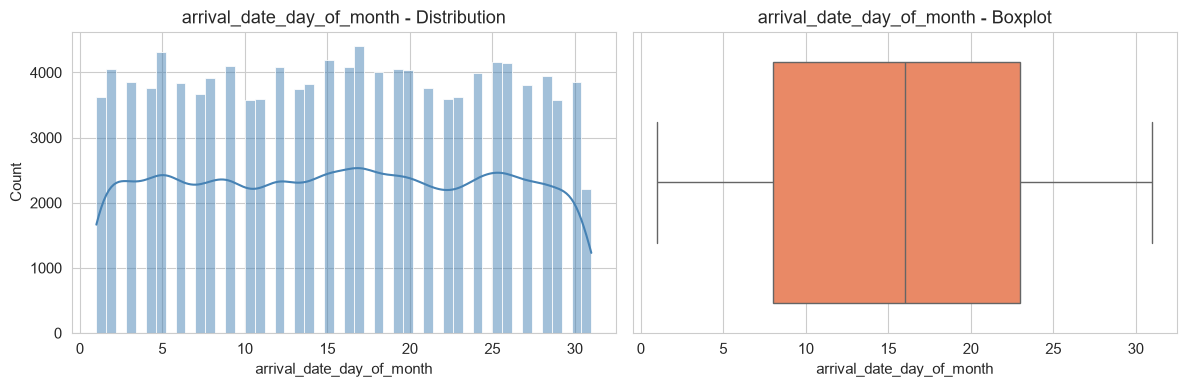

In [64]:
print('--- arrival_date_day_of_month ---')
print(hotel_df['arrival_date_day_of_month'].describe())
print(f"Missing: {hotel_df['arrival_date_day_of_month'].isnull().sum()}")
if hotel_df['arrival_date_day_of_month'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['arrival_date_day_of_month'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['arrival_date_day_of_month'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['arrival_date_day_of_month'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('arrival_date_day_of_month - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('arrival_date_day_of_month - Distribution')
sns.boxplot(x=hotel_df['arrival_date_day_of_month'], ax=axes[1], color='coral')
axes[1].set_title('arrival_date_day_of_month - Boxplot')
plt.tight_layout()
plt.show()


### `stays_in_weekend_nights`

Number of weekend nights stayed.


--- stays_in_weekend_nights ---
count    119390.000000
mean          0.927599
std           0.998613
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          19.000000
Name: stays_in_weekend_nights, dtype: float64
Missing: 0
Skewness: 1.38


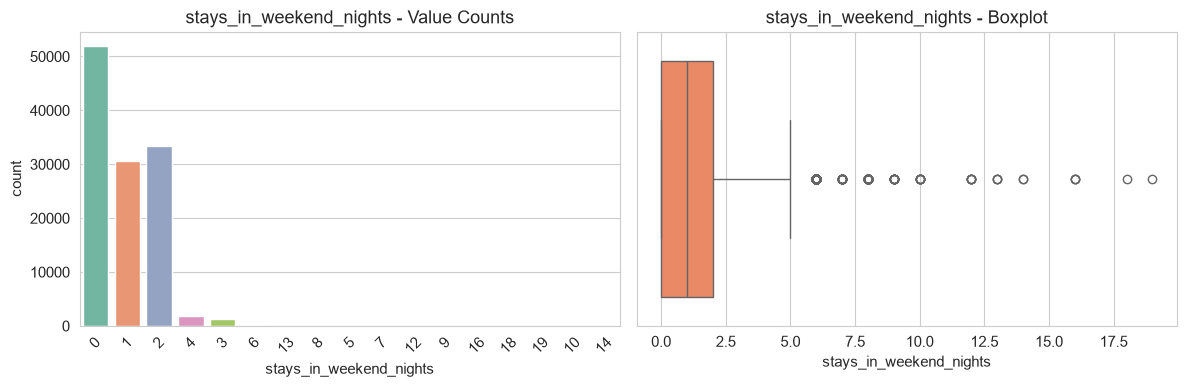

In [65]:
print('--- stays_in_weekend_nights ---')
print(hotel_df['stays_in_weekend_nights'].describe())
print(f"Missing: {hotel_df['stays_in_weekend_nights'].isnull().sum()}")
if hotel_df['stays_in_weekend_nights'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['stays_in_weekend_nights'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['stays_in_weekend_nights'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['stays_in_weekend_nights'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('stays_in_weekend_nights - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('stays_in_weekend_nights - Distribution')
sns.boxplot(x=hotel_df['stays_in_weekend_nights'], ax=axes[1], color='coral')
axes[1].set_title('stays_in_weekend_nights - Boxplot')
plt.tight_layout()
plt.show()


### `stays_in_week_nights`

Number of week nights stayed.


--- stays_in_week_nights ---
count    119390.000000
mean          2.500302
std           1.908286
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          50.000000
Name: stays_in_week_nights, dtype: float64
Missing: 0
Skewness: 2.86


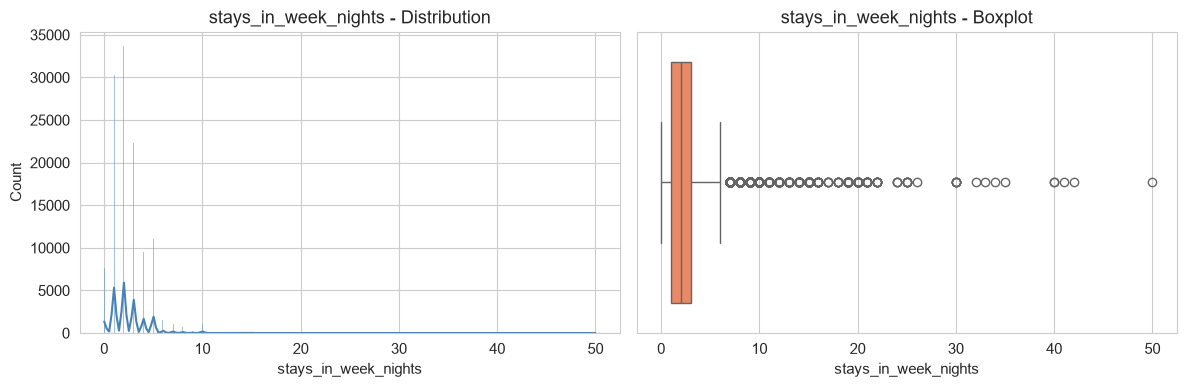

In [66]:
print('--- stays_in_week_nights ---')
print(hotel_df['stays_in_week_nights'].describe())
print(f"Missing: {hotel_df['stays_in_week_nights'].isnull().sum()}")
if hotel_df['stays_in_week_nights'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['stays_in_week_nights'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['stays_in_week_nights'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['stays_in_week_nights'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('stays_in_week_nights - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('stays_in_week_nights - Distribution')
sns.boxplot(x=hotel_df['stays_in_week_nights'], ax=axes[1], color='coral')
axes[1].set_title('stays_in_week_nights - Boxplot')
plt.tight_layout()
plt.show()


### `adults`

Number of adults.


--- adults ---
count    119390.000000
mean          1.856403
std           0.579261
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: adults, dtype: float64
Missing: 0
Skewness: 18.32


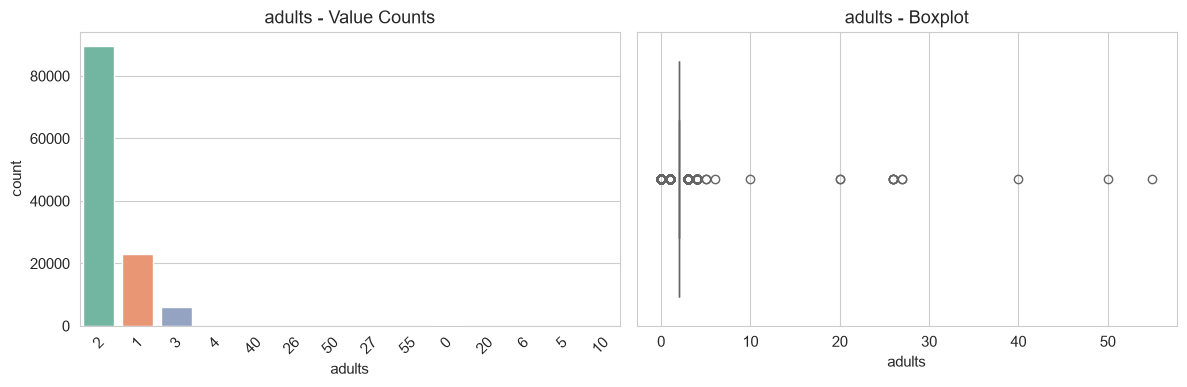

In [67]:
print('--- adults ---')
print(hotel_df['adults'].describe())
print(f"Missing: {hotel_df['adults'].isnull().sum()}")
if hotel_df['adults'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['adults'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['adults'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['adults'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('adults - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('adults - Distribution')
sns.boxplot(x=hotel_df['adults'], ax=axes[1], color='coral')
axes[1].set_title('adults - Boxplot')
plt.tight_layout()
plt.show()


### `children`

Number of children.


--- children ---
count    119386.000000
mean          0.103890
std           0.398561
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: children, dtype: float64
Missing: 4
Skewness: 4.11


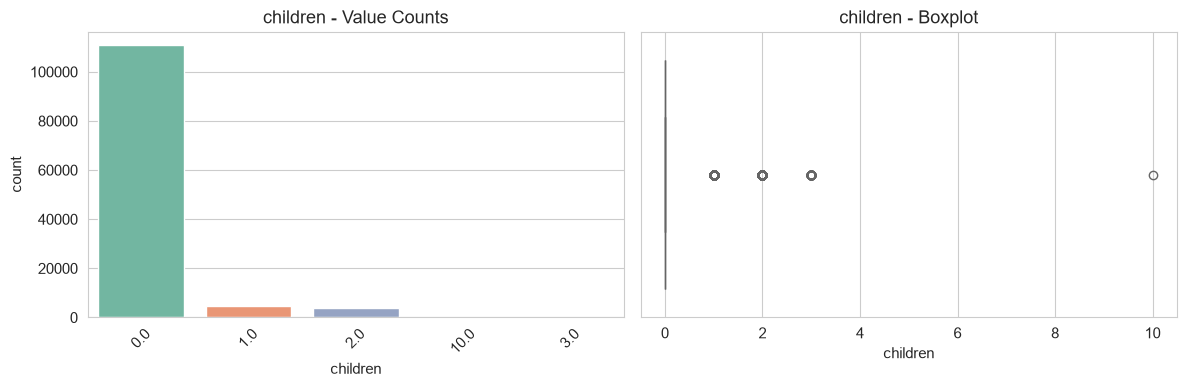

In [68]:
print('--- children ---')
print(hotel_df['children'].describe())
print(f"Missing: {hotel_df['children'].isnull().sum()}")
if hotel_df['children'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['children'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['children'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['children'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('children - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('children - Distribution')
sns.boxplot(x=hotel_df['children'], ax=axes[1], color='coral')
axes[1].set_title('children - Boxplot')
plt.tight_layout()
plt.show()


### `babies`

Number of babies.


--- babies ---
count    119390.000000
mean          0.007949
std           0.097436
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: babies, dtype: float64
Missing: 0
Skewness: 24.65


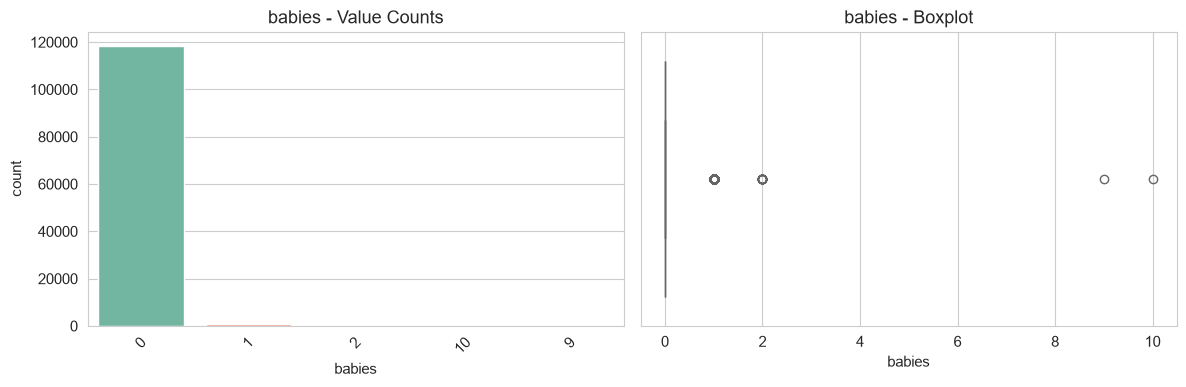

In [69]:
print('--- babies ---')
print(hotel_df['babies'].describe())
print(f"Missing: {hotel_df['babies'].isnull().sum()}")
if hotel_df['babies'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['babies'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['babies'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['babies'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('babies - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('babies - Distribution')
sns.boxplot(x=hotel_df['babies'], ax=axes[1], color='coral')
axes[1].set_title('babies - Boxplot')
plt.tight_layout()
plt.show()


### `meal`

Meal plan booked.


--- meal ---
Unique values: 5
Missing: 0
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


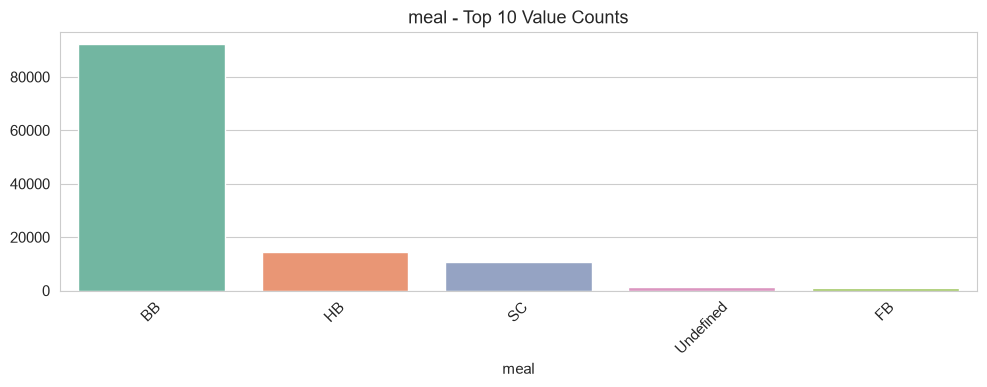

In [70]:
print('--- meal ---')
print(f"Unique values: {hotel_df['meal'].nunique()}")
print(f"Missing: {hotel_df['meal'].isnull().sum()}")
print(hotel_df['meal'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['meal'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('meal - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `country`

Country of origin (ISO codes).


--- country ---
Unique values: 177
Missing: 488
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64


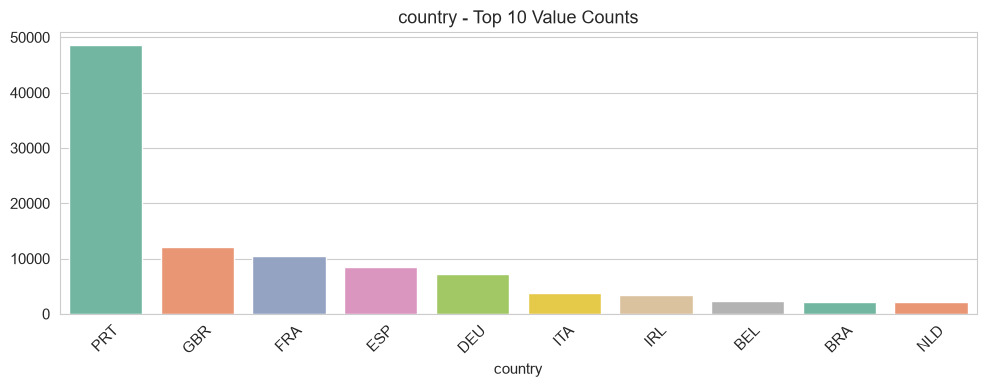

In [71]:
print('--- country ---')
print(f"Unique values: {hotel_df['country'].nunique()}")
print(f"Missing: {hotel_df['country'].isnull().sum()}")
print(hotel_df['country'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['country'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('country - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `market_segment`

Market segment designation.


--- market_segment ---
Unique values: 8
Missing: 0
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


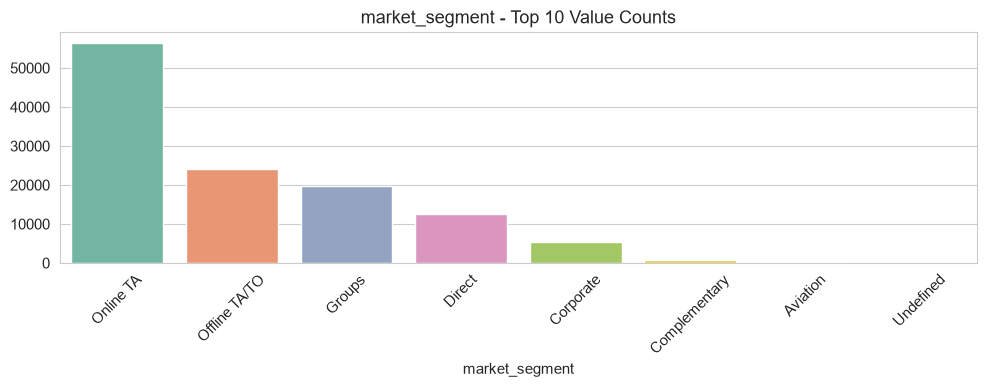

In [72]:
print('--- market_segment ---')
print(f"Unique values: {hotel_df['market_segment'].nunique()}")
print(f"Missing: {hotel_df['market_segment'].isnull().sum()}")
print(hotel_df['market_segment'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['market_segment'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('market_segment - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `distribution_channel`

Booking distribution channel.


--- distribution_channel ---
Unique values: 5
Missing: 0
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64


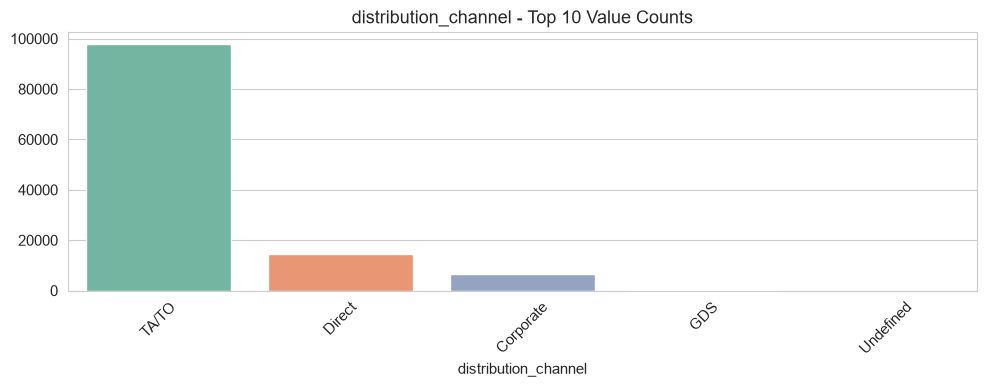

In [73]:
print('--- distribution_channel ---')
print(f"Unique values: {hotel_df['distribution_channel'].nunique()}")
print(f"Missing: {hotel_df['distribution_channel'].isnull().sum()}")
print(hotel_df['distribution_channel'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['distribution_channel'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('distribution_channel - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `is_repeated_guest`

Whether guest has stayed before (0/1).


--- is_repeated_guest ---
count    119390.000000
mean          0.031912
std           0.175767
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: is_repeated_guest, dtype: float64
Missing: 0
Skewness: 5.33


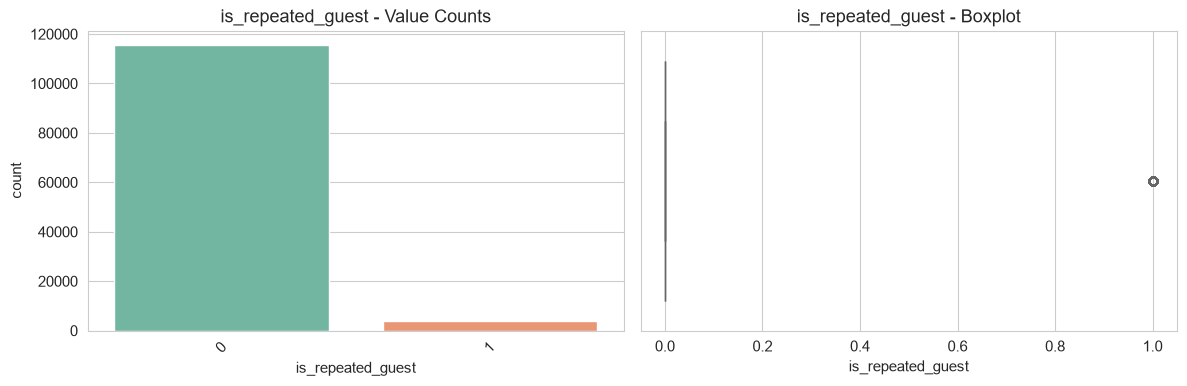

In [74]:
print('--- is_repeated_guest ---')
print(hotel_df['is_repeated_guest'].describe())
print(f"Missing: {hotel_df['is_repeated_guest'].isnull().sum()}")
if hotel_df['is_repeated_guest'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['is_repeated_guest'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['is_repeated_guest'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['is_repeated_guest'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('is_repeated_guest - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('is_repeated_guest - Distribution')
sns.boxplot(x=hotel_df['is_repeated_guest'], ax=axes[1], color='coral')
axes[1].set_title('is_repeated_guest - Boxplot')
plt.tight_layout()
plt.show()


### `previous_cancellations`

Previous booking cancellations.


--- previous_cancellations ---
count    119390.000000
mean          0.087118
std           0.844336
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          26.000000
Name: previous_cancellations, dtype: float64
Missing: 0
Skewness: 24.46


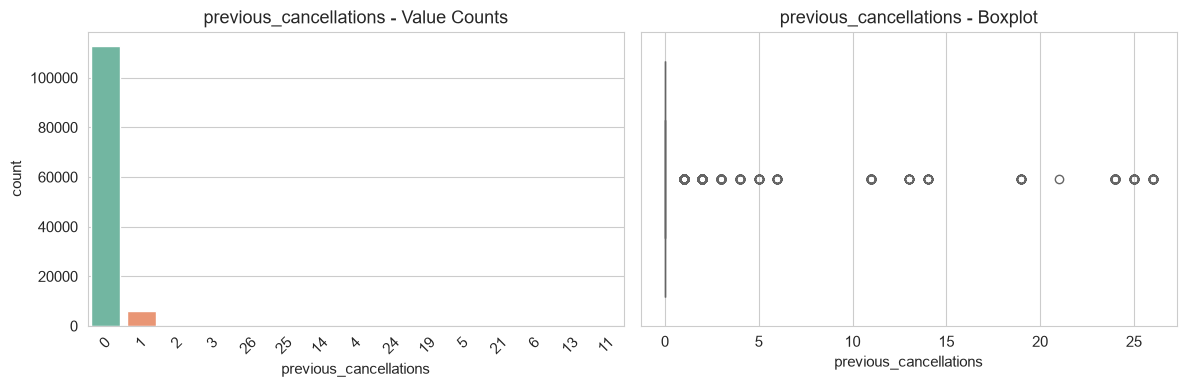

In [75]:
print('--- previous_cancellations ---')
print(hotel_df['previous_cancellations'].describe())
print(f"Missing: {hotel_df['previous_cancellations'].isnull().sum()}")
if hotel_df['previous_cancellations'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['previous_cancellations'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['previous_cancellations'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['previous_cancellations'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('previous_cancellations - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('previous_cancellations - Distribution')
sns.boxplot(x=hotel_df['previous_cancellations'], ax=axes[1], color='coral')
axes[1].set_title('previous_cancellations - Boxplot')
plt.tight_layout()
plt.show()


### `previous_bookings_not_canceled`

Previous bookings not canceled.


--- previous_bookings_not_canceled ---
count    119390.000000
mean          0.137097
std           1.497437
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          72.000000
Name: previous_bookings_not_canceled, dtype: float64
Missing: 0
Skewness: 23.54


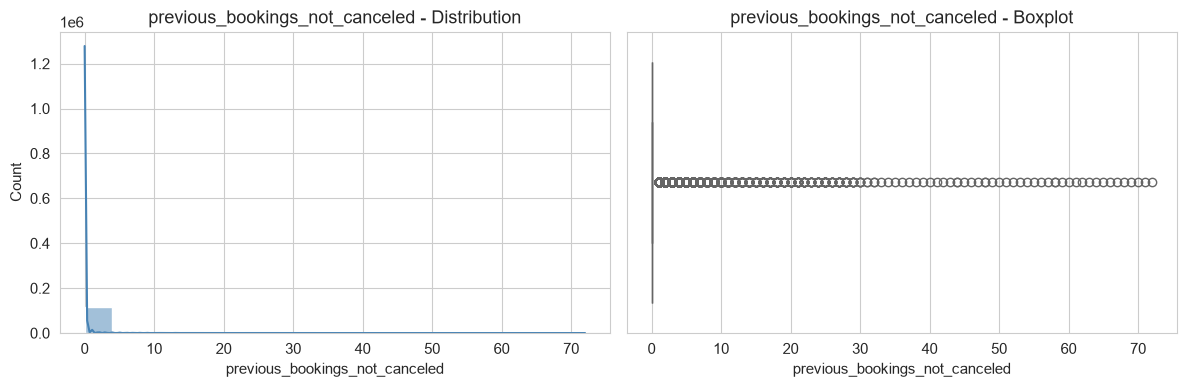

In [76]:
print('--- previous_bookings_not_canceled ---')
print(hotel_df['previous_bookings_not_canceled'].describe())
print(f"Missing: {hotel_df['previous_bookings_not_canceled'].isnull().sum()}")
if hotel_df['previous_bookings_not_canceled'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['previous_bookings_not_canceled'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['previous_bookings_not_canceled'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['previous_bookings_not_canceled'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('previous_bookings_not_canceled - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('previous_bookings_not_canceled - Distribution')
sns.boxplot(x=hotel_df['previous_bookings_not_canceled'], ax=axes[1], color='coral')
axes[1].set_title('previous_bookings_not_canceled - Boxplot')
plt.tight_layout()
plt.show()


### `reserved_room_type`

Room type reserved.


--- reserved_room_type ---
Unique values: 10
Missing: 0
reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64


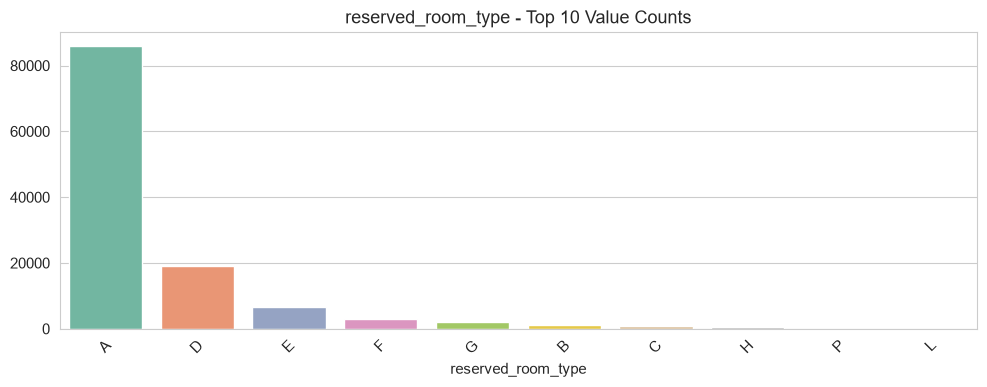

In [77]:
print('--- reserved_room_type ---')
print(f"Unique values: {hotel_df['reserved_room_type'].nunique()}")
print(f"Missing: {hotel_df['reserved_room_type'].isnull().sum()}")
print(hotel_df['reserved_room_type'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['reserved_room_type'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('reserved_room_type - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `assigned_room_type`

Room type assigned.


--- assigned_room_type ---
Unique values: 12
Missing: 0
assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H      712
I      363
K      279
Name: count, dtype: int64


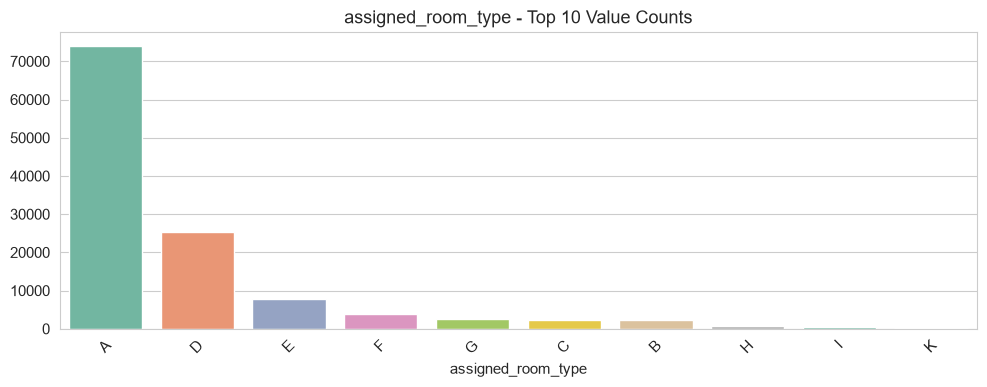

In [78]:
print('--- assigned_room_type ---')
print(f"Unique values: {hotel_df['assigned_room_type'].nunique()}")
print(f"Missing: {hotel_df['assigned_room_type'].isnull().sum()}")
print(hotel_df['assigned_room_type'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['assigned_room_type'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('assigned_room_type - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `booking_changes`

Number of booking changes.


--- booking_changes ---
count    119390.000000
mean          0.221124
std           0.652306
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: booking_changes, dtype: float64
Missing: 0
Skewness: 6.00


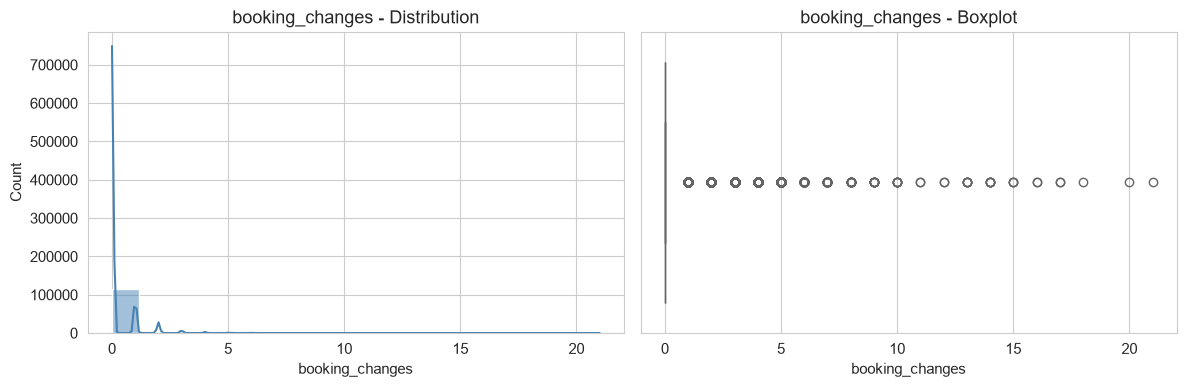

In [79]:
print('--- booking_changes ---')
print(hotel_df['booking_changes'].describe())
print(f"Missing: {hotel_df['booking_changes'].isnull().sum()}")
if hotel_df['booking_changes'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['booking_changes'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['booking_changes'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['booking_changes'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('booking_changes - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('booking_changes - Distribution')
sns.boxplot(x=hotel_df['booking_changes'], ax=axes[1], color='coral')
axes[1].set_title('booking_changes - Boxplot')
plt.tight_layout()
plt.show()


### `deposit_type`

Deposit type made.


--- deposit_type ---
Unique values: 3
Missing: 0
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64


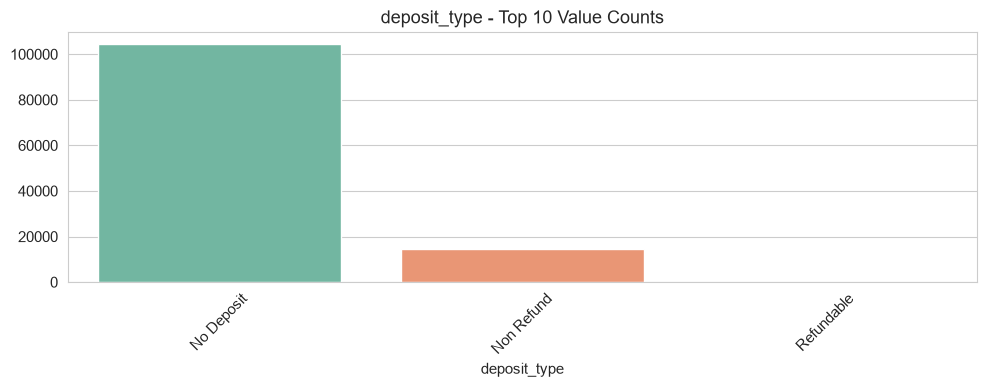

In [80]:
print('--- deposit_type ---')
print(f"Unique values: {hotel_df['deposit_type'].nunique()}")
print(f"Missing: {hotel_df['deposit_type'].isnull().sum()}")
print(hotel_df['deposit_type'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['deposit_type'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('deposit_type - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `agent`

Travel agency ID.


--- agent ---
count    103050.000000
mean         86.693382
std         110.774548
min           1.000000
25%           9.000000
50%          14.000000
75%         229.000000
max         535.000000
Name: agent, dtype: float64
Missing: 16340
Skewness: 1.09


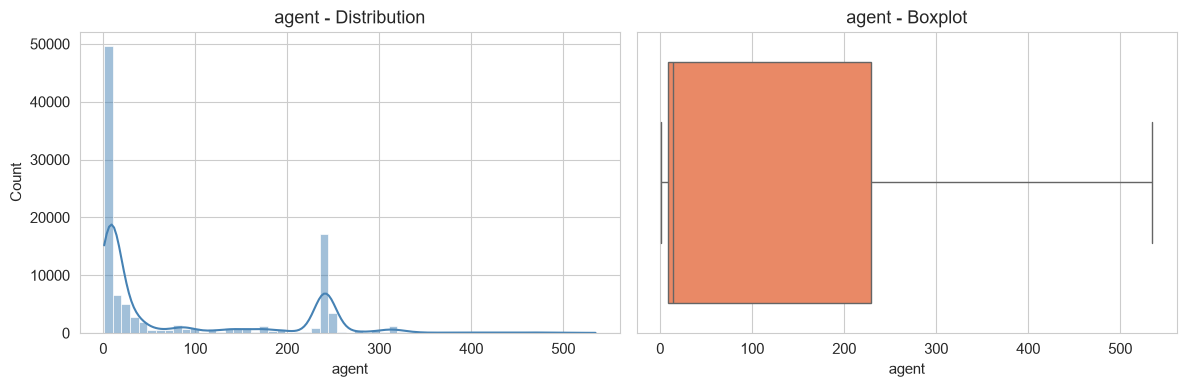

In [81]:
print('--- agent ---')
print(hotel_df['agent'].describe())
print(f"Missing: {hotel_df['agent'].isnull().sum()}")
if hotel_df['agent'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['agent'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['agent'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['agent'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('agent - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('agent - Distribution')
sns.boxplot(x=hotel_df['agent'], ax=axes[1], color='coral')
axes[1].set_title('agent - Boxplot')
plt.tight_layout()
plt.show()


### `company`

Company ID.


--- company ---
count    6797.000000
mean      189.266735
std       131.655015
min         6.000000
25%        62.000000
50%       179.000000
75%       270.000000
max       543.000000
Name: company, dtype: float64
Missing: 112593
Skewness: 0.60


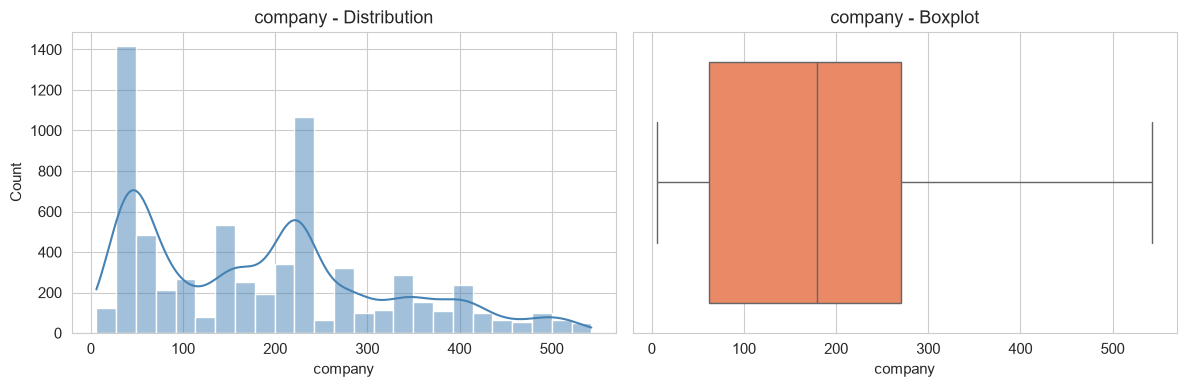

In [82]:
print('--- company ---')
print(hotel_df['company'].describe())
print(f"Missing: {hotel_df['company'].isnull().sum()}")
if hotel_df['company'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['company'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['company'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['company'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('company - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('company - Distribution')
sns.boxplot(x=hotel_df['company'], ax=axes[1], color='coral')
axes[1].set_title('company - Boxplot')
plt.tight_layout()
plt.show()


### `days_in_waiting_list`

Days on waiting list.


--- days_in_waiting_list ---
count    119390.000000
mean          2.321149
std          17.594721
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         391.000000
Name: days_in_waiting_list, dtype: float64
Missing: 0
Skewness: 11.94


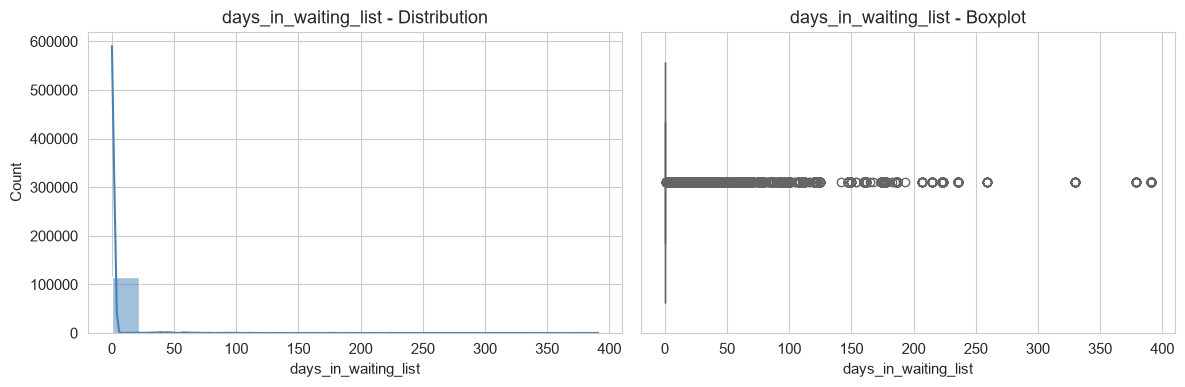

In [83]:
print('--- days_in_waiting_list ---')
print(hotel_df['days_in_waiting_list'].describe())
print(f"Missing: {hotel_df['days_in_waiting_list'].isnull().sum()}")
if hotel_df['days_in_waiting_list'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['days_in_waiting_list'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['days_in_waiting_list'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['days_in_waiting_list'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('days_in_waiting_list - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('days_in_waiting_list - Distribution')
sns.boxplot(x=hotel_df['days_in_waiting_list'], ax=axes[1], color='coral')
axes[1].set_title('days_in_waiting_list - Boxplot')
plt.tight_layout()
plt.show()


### `customer_type`

Customer type (Transient, Contract, etc.).


--- customer_type ---
Unique values: 4
Missing: 0
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


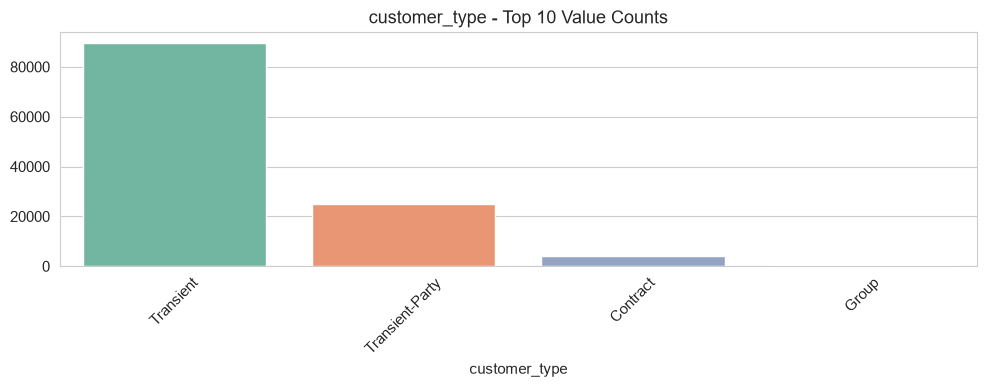

In [84]:
print('--- customer_type ---')
print(f"Unique values: {hotel_df['customer_type'].nunique()}")
print(f"Missing: {hotel_df['customer_type'].isnull().sum()}")
print(hotel_df['customer_type'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['customer_type'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('customer_type - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `adr`

Average Daily Rate.


--- adr ---
count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64
Missing: 0
Skewness: 10.53


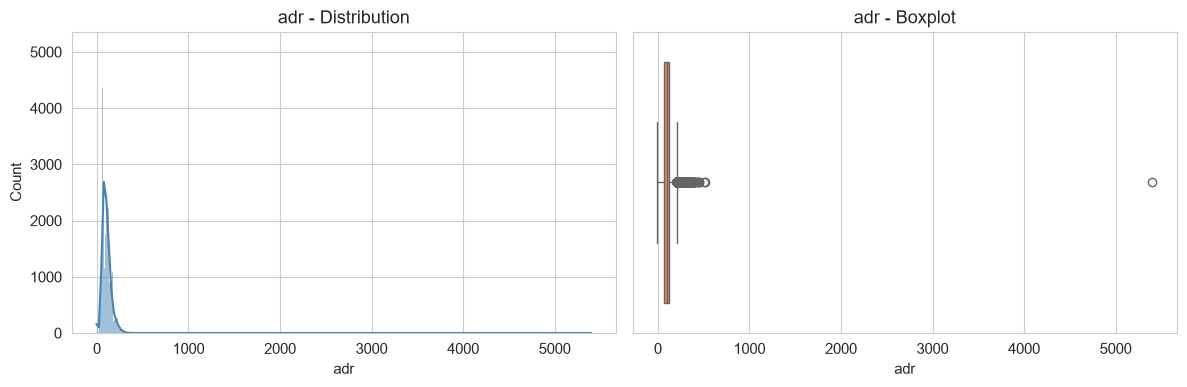

In [85]:
print('--- adr ---')
print(hotel_df['adr'].describe())
print(f"Missing: {hotel_df['adr'].isnull().sum()}")
if hotel_df['adr'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['adr'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['adr'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['adr'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('adr - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('adr - Distribution')
sns.boxplot(x=hotel_df['adr'], ax=axes[1], color='coral')
axes[1].set_title('adr - Boxplot')
plt.tight_layout()
plt.show()


### `required_car_parking_spaces`

Required car parking spaces.


--- required_car_parking_spaces ---
count    119390.000000
mean          0.062518
std           0.245291
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: required_car_parking_spaces, dtype: float64
Missing: 0
Skewness: 4.16


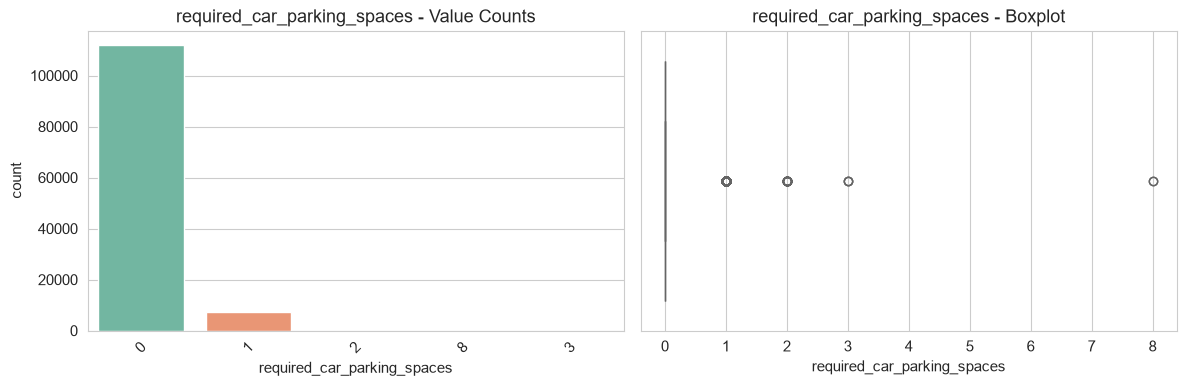

In [86]:
print('--- required_car_parking_spaces ---')
print(hotel_df['required_car_parking_spaces'].describe())
print(f"Missing: {hotel_df['required_car_parking_spaces'].isnull().sum()}")
if hotel_df['required_car_parking_spaces'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['required_car_parking_spaces'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['required_car_parking_spaces'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['required_car_parking_spaces'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('required_car_parking_spaces - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('required_car_parking_spaces - Distribution')
sns.boxplot(x=hotel_df['required_car_parking_spaces'], ax=axes[1], color='coral')
axes[1].set_title('required_car_parking_spaces - Boxplot')
plt.tight_layout()
plt.show()


### `total_of_special_requests`

Total special requests made.


--- total_of_special_requests ---
count    119390.000000
mean          0.571363
std           0.792798
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           5.000000
Name: total_of_special_requests, dtype: float64
Missing: 0
Skewness: 1.35


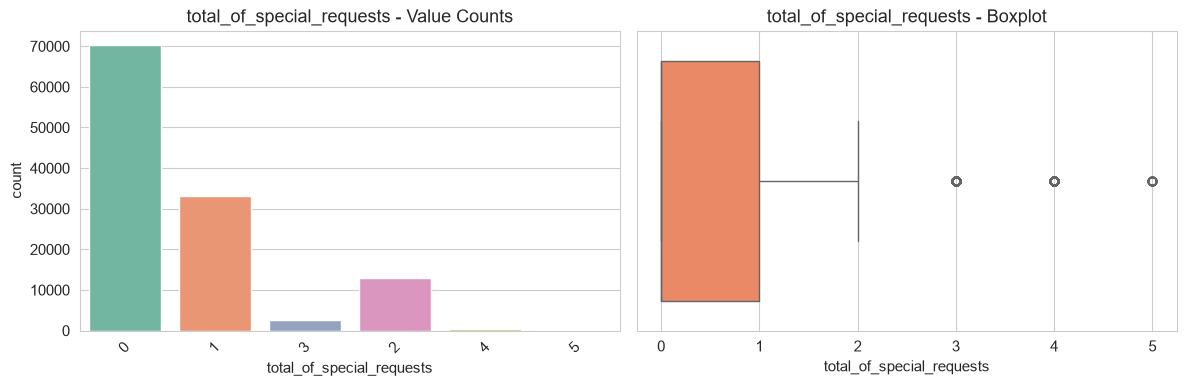

In [87]:
print('--- total_of_special_requests ---')
print(hotel_df['total_of_special_requests'].describe())
print(f"Missing: {hotel_df['total_of_special_requests'].isnull().sum()}")
if hotel_df['total_of_special_requests'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['total_of_special_requests'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['total_of_special_requests'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['total_of_special_requests'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('total_of_special_requests - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('total_of_special_requests - Distribution')
sns.boxplot(x=hotel_df['total_of_special_requests'], ax=axes[1], color='coral')
axes[1].set_title('total_of_special_requests - Boxplot')
plt.tight_layout()
plt.show()


### `reservation_status`

Reservation status at last check.


--- reservation_status ---
Unique values: 3
Missing: 0
reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64


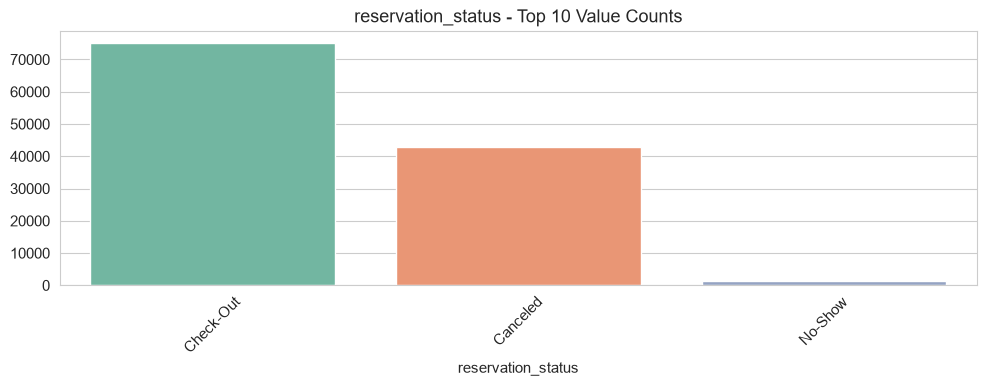

In [88]:
print('--- reservation_status ---')
print(f"Unique values: {hotel_df['reservation_status'].nunique()}")
print(f"Missing: {hotel_df['reservation_status'].isnull().sum()}")
print(hotel_df['reservation_status'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['reservation_status'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('reservation_status - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `reservation_status_date`

Date of last status update.


--- reservation_status_date ---
Unique values: 926
Missing: 0
reservation_status_date
2015-10-21    1461
2015-07-06     805
2016-11-25     790
2015-01-01     763
2016-01-18     625
2015-07-02     469
2016-12-07     450
2015-12-18     423
2016-02-09     412
2016-04-04     382
Name: count, dtype: int64


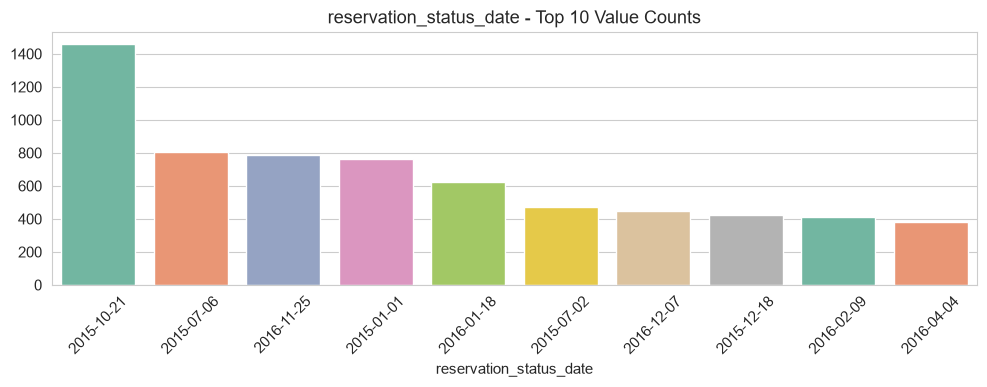

In [89]:
print('--- reservation_status_date ---')
print(f"Unique values: {hotel_df['reservation_status_date'].nunique()}")
print(f"Missing: {hotel_df['reservation_status_date'].isnull().sum()}")
print(hotel_df['reservation_status_date'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['reservation_status_date'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('reservation_status_date - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `name`

Guest name (PII).


--- name ---
Unique values: 81503
Missing: 0
name
Michael Johnson      48
Robert Smith         48
Michael Smith        47
John Smith           46
Christopher Smith    44
Jennifer Smith       42
James Smith          39
David Smith          36
Michael Williams     35
Christopher Jones    31
Name: count, dtype: int64


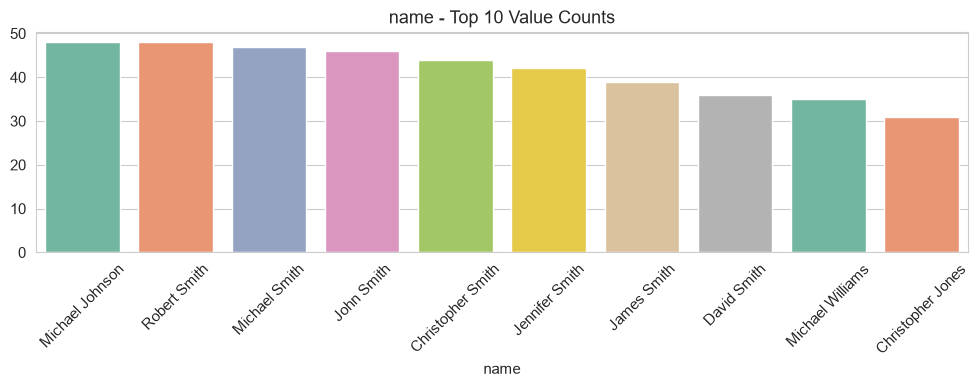

In [90]:
print('--- name ---')
print(f"Unique values: {hotel_df['name'].nunique()}")
print(f"Missing: {hotel_df['name'].isnull().sum()}")
print(hotel_df['name'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['name'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('name - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `email`

Guest email (PII).


--- email ---
Unique values: 115889
Missing: 0


email
Michael.C@gmail.com          6
JSmith@gmail.com             5
JMiller@gmail.com            5
James.M@mail.com             5
Robert.M@outlook.com         5
ASmith@yahoo.com             5
TJohnson@outlook.com         5
Christopher.W@hotmail.com    5
JJohnson@hotmail.com         5
KJohnson@gmail.com           5
Name: count, dtype: int64


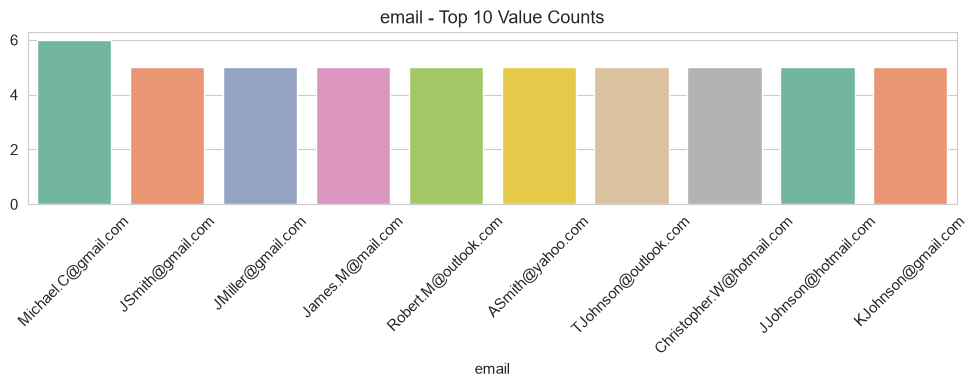

In [91]:
print('--- email ---')
print(f"Unique values: {hotel_df['email'].nunique()}")
print(f"Missing: {hotel_df['email'].isnull().sum()}")
print(hotel_df['email'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['email'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('email - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `phone-number`

Guest phone number (PII).


--- phone-number ---
Unique values: 119390
Missing: 0
phone-number
669-792-1661    1
858-637-6955    1
652-885-2745    1
364-656-8427    1
713-226-5883    1
190-271-6743    1
420-332-5209    1
286-669-4333    1
341-726-5787    1
316-648-6176    1
Name: count, dtype: int64


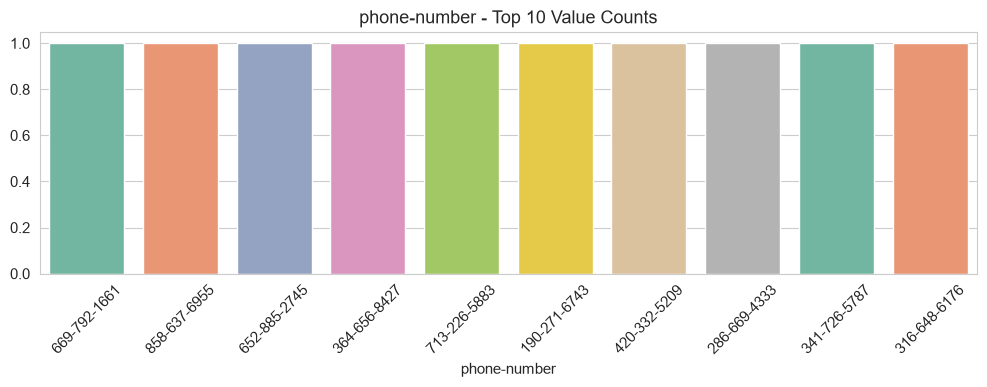

In [92]:
print('--- phone-number ---')
print(f"Unique values: {hotel_df['phone-number'].nunique()}")
print(f"Missing: {hotel_df['phone-number'].isnull().sum()}")
print(hotel_df['phone-number'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['phone-number'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('phone-number - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `credit_card`

Masked credit card number (PII).


--- credit_card ---
Unique values: 9000
Missing: 0


credit_card
************3627    28
************4923    28
************3793    27
************9864    27
************3972    27
************3352    26
************8172    26
************8794    26
************7474    26
************4681    26
Name: count, dtype: int64


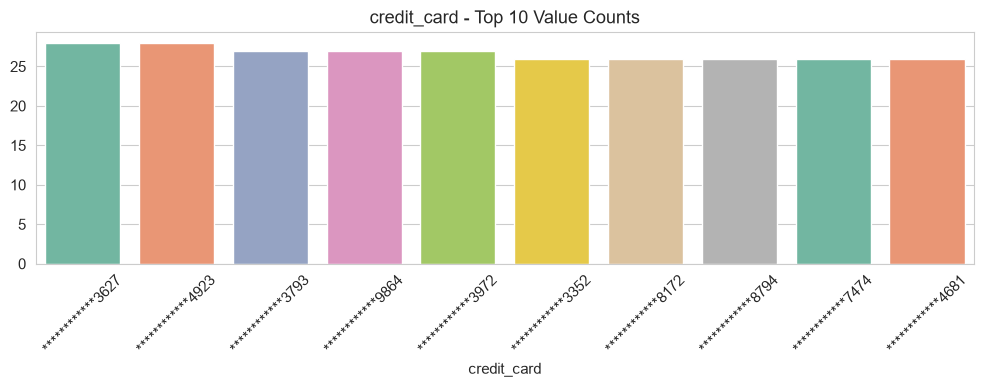

In [93]:
print('--- credit_card ---')
print(f"Unique values: {hotel_df['credit_card'].nunique()}")
print(f"Missing: {hotel_df['credit_card'].isnull().sum()}")
print(hotel_df['credit_card'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['credit_card'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('credit_card - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Correlation Analysis (Numerical Columns)


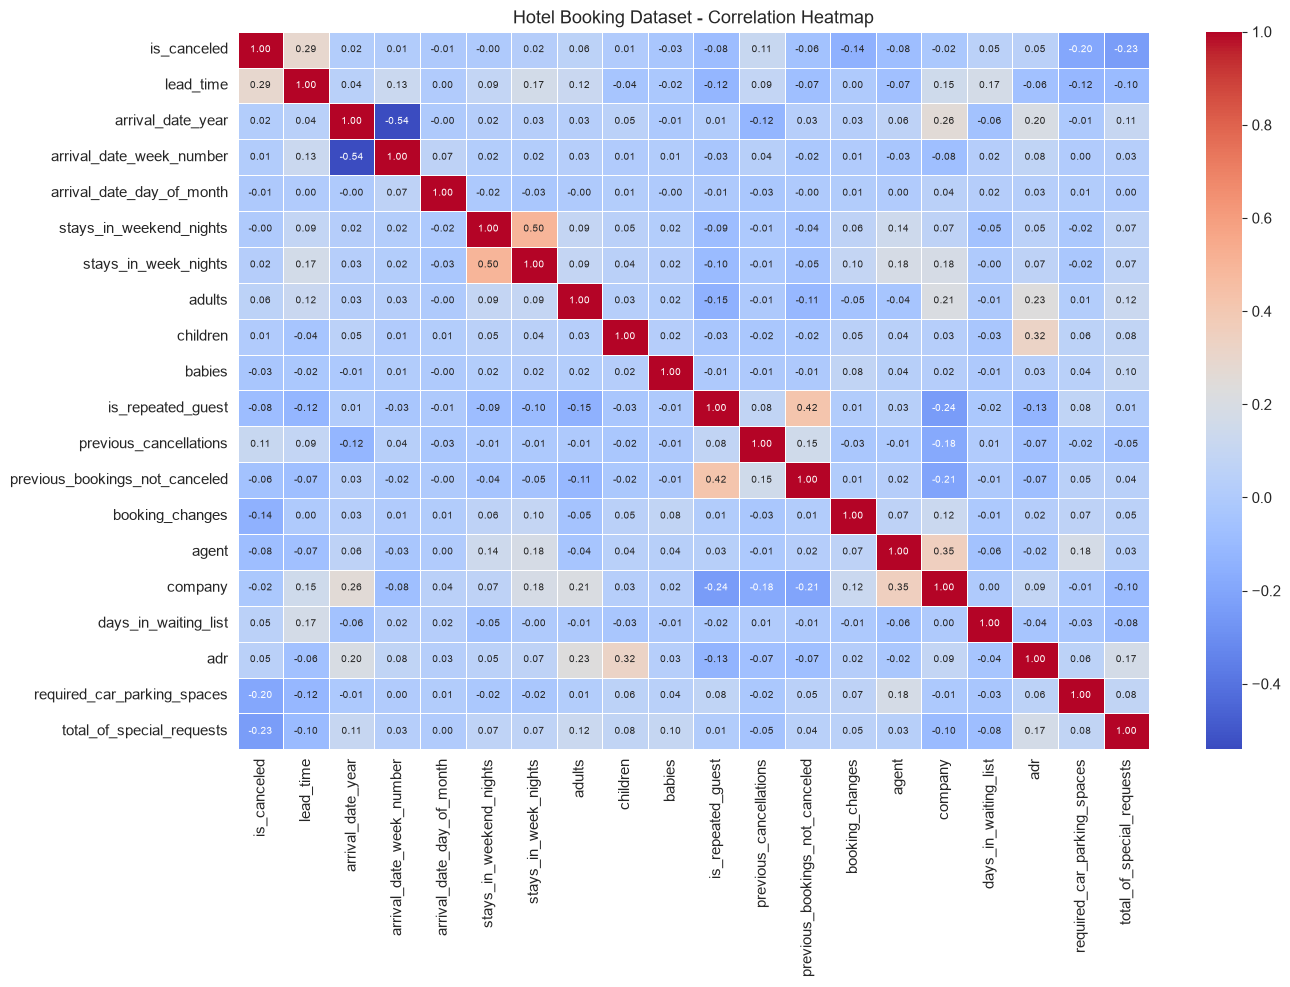

In [94]:
num_cols_hotel = hotel_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(hotel_df[num_cols_hotel].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={'size': 7})
plt.title('Hotel Booking Dataset - Correlation Heatmap')
plt.tight_layout()
plt.show()


## Target Variable Analysis: `is_canceled`


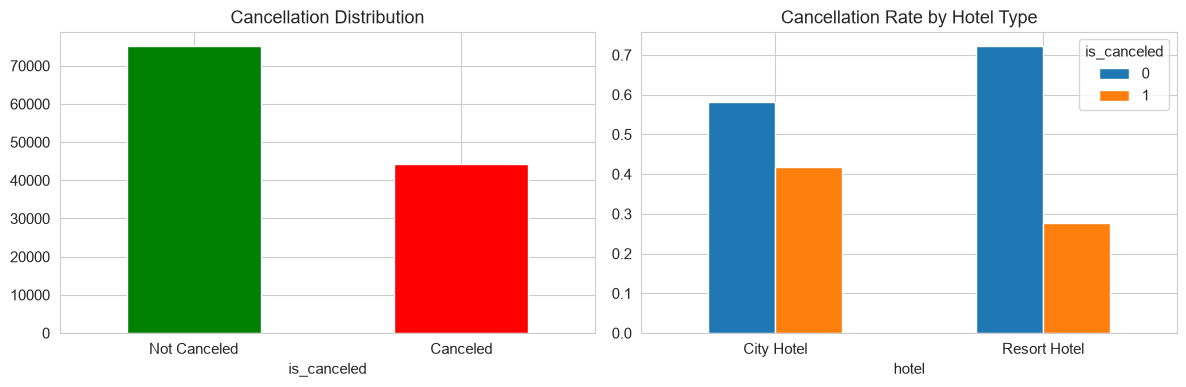

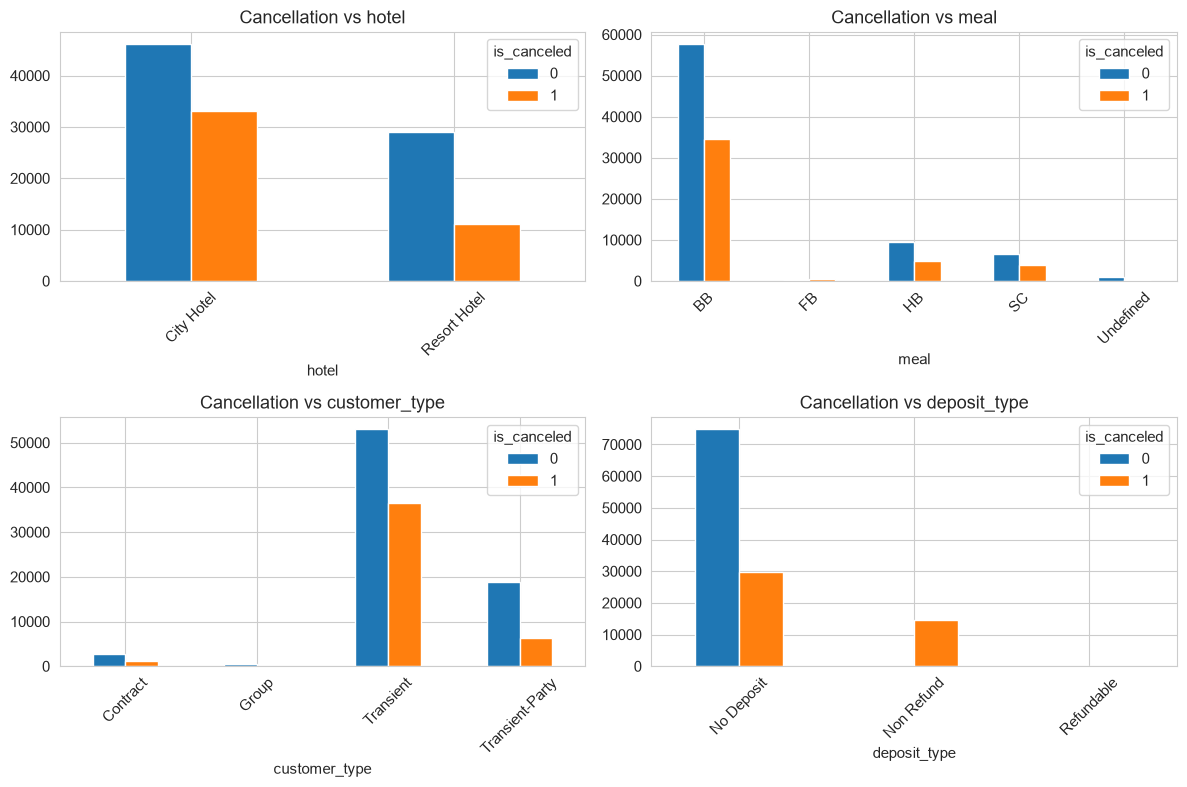

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hotel_df['is_canceled'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Cancellation Distribution')
axes[0].set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

pd.crosstab(hotel_df['hotel'], hotel_df['is_canceled'], normalize='index').plot(kind='bar', ax=axes[1])
axes[1].set_title('Cancellation Rate by Hotel Type')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(['hotel', 'meal', 'customer_type', 'deposit_type']):
    pd.crosstab(hotel_df[col], hotel_df['is_canceled']).plot(kind='bar', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Cancellation vs {col}')
    axes[i//2, i%2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Data Cleaning - Hotel Booking Dataset

Cleaning steps:
1. Drop PII columns (`name`, `email`, `phone-number`, `credit_card`) - not needed for analysis
2. Drop `reservation_status` and `reservation_status_date` (data leakage with target)
3. Impute missing `country` with mode
4. Impute missing `children` with 0
5. Fill `agent` and `company` with 0 (no agent/company)
6. Remove rows with negative ADR or zero adults
7. Convert `agent` and `company` to integer


In [96]:
hotel_clean = hotel_df.copy()

# Drop PII and leakage columns
drop_cols = ['name', 'email', 'phone-number', 'credit_card',
             'reservation_status', 'reservation_status_date']
hotel_clean = hotel_clean.drop(columns=drop_cols)
print(f'Dropped columns: {drop_cols}')

# Impute country with mode
country_mode = hotel_clean['country'].mode()[0]
hotel_clean['country'] = hotel_clean['country'].fillna(country_mode)
print(f'country: filled with mode = {country_mode}')

# Impute children with 0
hotel_clean['children'] = hotel_clean['children'].fillna(0)
print('children: filled with 0')

# Fill agent and company with 0 (no agent/company)
hotel_clean['agent'] = hotel_clean['agent'].fillna(0)
hotel_clean['company'] = hotel_clean['company'].fillna(0)
print('agent, company: filled with 0')

# Remove invalid records
before_len = len(hotel_clean)
hotel_clean = hotel_clean[hotel_clean['adr'] >= 0]
hotel_clean = hotel_clean[hotel_clean['adults'] >= 1]
print(f'Removed {before_len - len(hotel_clean)} invalid rows (negative ADR or zero adults)')

# Convert to integer
hotel_clean['agent'] = hotel_clean['agent'].astype(int)
hotel_clean['company'] = hotel_clean['company'].astype(int)
hotel_clean['children'] = hotel_clean['children'].astype(int)

print('\nMissing values after cleaning:')
print(hotel_clean.isnull().sum().sum())


Dropped columns: ['name', 'email', 'phone-number', 'credit_card', 'reservation_status', 'reservation_status_date']
country: filled with mode = PRT
children: filled with 0
agent, company: filled with 0
Removed 404 invalid rows (negative ADR or zero adults)

Missing values after cleaning:


0


In [97]:
print('Before cleaning shape:', hotel_original.shape)
print('After cleaning shape:', hotel_clean.shape)
print('\nCleaned dataset info:')
hotel_clean.info()
hotel_clean.head()


Before cleaning shape: (119390, 36)
After cleaning shape: (118986, 30)

Cleaned dataset info:
<class 'pandas.DataFrame'>
Index: 118986 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118986 non-null  str    
 1   is_canceled                     118986 non-null  int64  
 2   lead_time                       118986 non-null  int64  
 3   arrival_date_year               118986 non-null  int64  
 4   arrival_date_month              118986 non-null  str    
 5   arrival_date_week_number        118986 non-null  int64  
 6   arrival_date_day_of_month       118986 non-null  int64  
 7   stays_in_weekend_nights         118986 non-null  int64  
 8   stays_in_week_nights            118986 non-null  int64  
 9   adults                          118986 non-null  int64  
 10  children                        118986 non-null  int32  
 11  

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,0,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,0,Transient,98.0,0,1


In [98]:
print('--- Before vs After Missing Values ---')
comparison_hotel = pd.DataFrame({
    'Before': hotel_original.isnull().sum(),
    'After': hotel_clean.reindex(columns=hotel_original.columns, fill_value=0).isnull().sum()
})
# Show only columns that had missing values before
cols_with_missing = hotel_original.isnull().sum()
cols_with_missing = cols_with_missing[cols_with_missing > 0].index
for col in cols_with_missing:
    if col in hotel_clean.columns:
        print(f'{col}: before={hotel_original[col].isnull().sum()}, after={hotel_clean[col].isnull().sum()}')
    else:
        print(f'{col}: dropped during cleaning')


--- Before vs After Missing Values ---


children: before=4, after=0
country: before=488, after=0
agent: before=16340, after=0
company: before=112593, after=0


---
# Summary

| Dataset | Original Shape | Cleaned Shape | Key Actions |
|---------|---------------|---------------|-------------|
| Loan | (1614, 13) | (1614, 12) | Imputed missing values, dropped Loan_ID, converted Dependents |
| Adult | (48842, 15) | (48790, 14) | Replaced ?, removed duplicates, imputed missing, dropped fnlwgt |
| Hotel | (119390, 36) | (118986, 30) | Dropped PII/leakage cols, imputed missing, removed invalid rows |


In [99]:
print('=' * 50)
print('FINAL CLEANED DATASETS SUMMARY')
print('=' * 50)
print(f'\nLoan Clean:  {loan_clean.shape}')
print(f'Adult Clean: {adult_clean.shape}')
print(f'Hotel Clean: {hotel_clean.shape}')
print('\nAll datasets cleaned successfully!')


FINAL CLEANED DATASETS SUMMARY

Loan Clean:  (1614, 12)
Adult Clean: (48790, 14)
Hotel Clean: (118986, 30)

All datasets cleaned successfully!
